# **Model Interpretation, Governance, and Business Recommendations**

## Project
**Using Machine Learning to Predict Complaint Resolution Outcomes in Retail Banking: Evidence from Open Consumer Financial Complaint Data**

## Purpose of this notebook

This is the final notebook in the capstone analysis workflow. It converts the statistical and machine-learning outputs from the earlier notebooks into model interpretation, business findings, operational recommendations, governance considerations, and report-ready summary tables.

It continues from:

- `01_data_extraction.ipynb`
- `02_exploratory_analysis.ipynb`
- `03_hypothesis_tests.ipynb`
- `04_model_training.ipynb`

## What was enhanced in this version

This enriched version adds:

- clearer model-selection rationale using ROC-AUC and balanced performance;
- classwise interpretation for timely and non-timely response detection;
- non-timely risk-score threshold analysis for operational triage;
- RQ3 narrative-model interpretation using structured versus TF-IDF results;
- RQ4 company/state incremental-value interpretation;
- feature-family interpretation for random forest importance;
- structured and narrative coefficient interpretation guidance;
- company-response outcome distribution and classification interpretation;
- executive-ready findings, recommendations, limitations, and governance notes.

## Main outputs

This notebook creates final CSV tables and figures under:

- `outputs/tables/`
- `outputs/figures/`

The outputs are designed to support the final capstone report, appendices, and presentation materials.


## Interpretation Questions

This notebook answers the following practical questions:

1. Which model performed best and why?
2. Why is accuracy alone misleading in this imbalanced complaint dataset?
3. How well does the model identify rare non-timely complaints?
4. What threshold should be considered for non-timely risk triage?
5. Do customer narratives add predictive value beyond structured fields?
6. Do company and geography add predictive value beyond complaint characteristics?
7. Which variables and feature families appear most important?
8. Where does the model make the most errors?
9. Are errors concentrated by product, issue, company, state, channel, or year?
10. How should company-response outcome modeling be interpreted?
11. What business recommendations and governance controls follow from the analysis?
12. What limitations should be reported in the final capstone paper?


In [2]:
# -------------------------------------------------------------------
# Mount Google Drive
# -------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# -------------------------------------------------------------------
# Import libraries
# -------------------------------------------------------------------
from pathlib import Path
from datetime import datetime
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 200)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# -------------------------------------------------------------------
# Project folders and file paths
# -------------------------------------------------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/retail-complaint-resolution-ml")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_MODELS = PROJECT_ROOT / "outputs" / "models"

for folder in [DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_FIGURES, OUTPUT_MODELS]:
    folder.mkdir(parents=True, exist_ok=True)

PROCESSED_FILE = DATA_PROCESSED / "cfpb_retail_complaints_2017_2025.csv"

MODEL_PERFORMANCE_FILE = OUTPUT_TABLES / "model_training_performance_comparison.csv"
BEST_MODEL_SUMMARY_FILE = OUTPUT_TABLES / "model_training_best_model_summary.csv"

print("Project root:", PROJECT_ROOT)
print("Processed data file:", PROCESSED_FILE)
print("Model output folder:", OUTPUT_MODELS)
print("Processed file exists:", PROCESSED_FILE.exists())

Project root: /content/drive/MyDrive/retail-complaint-resolution-ml
Processed data file: /content/drive/MyDrive/retail-complaint-resolution-ml/data/processed/cfpb_retail_complaints_2017_2025.csv
Model output folder: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/models
Processed file exists: True


## Helper Functions for Final Interpretation

The helper functions below make the final notebook more robust. They safely load optional output tables from Notebook 04, save tables consistently, and standardize feature names for interpretation.


In [5]:
# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------
def save_table(dataframe, filename):
    """Save a DataFrame to outputs/tables and display the saved path."""
    path = OUTPUT_TABLES / filename
    dataframe.to_csv(path, index=False)
    print("Saved table:", path)
    return path


def safe_read_csv(path, label=None):
    """Read a CSV file only if it exists."""
    path = Path(path)
    if path.exists():
        table = pd.read_csv(path)
        print(f"Loaded {label or path.name}:", path)
        return table
    print(f"Not found {label or path.name}:", path)
    return pd.DataFrame()


def round_numeric_columns(dataframe, decimals=4):
    """Round numeric columns without changing non-numeric columns."""
    result = dataframe.copy()
    numeric_cols = result.select_dtypes(include=[np.number]).columns
    result[numeric_cols] = result[numeric_cols].round(decimals)
    return result


def clean_feature_name(feature):
    """Make encoded feature names easier to read in final tables."""
    feature = str(feature)
    feature = feature.replace("cat__", "")
    feature = feature.replace("num__", "")
    feature = feature.replace("text__", "text: ")
    feature = feature.replace("_", " ")
    return feature


def feature_family(feature):
    """Map encoded feature names to business-friendly feature families."""
    feature = str(feature)
    if "company_grouped" in feature:
        return "Company group"
    if "state_grouped" in feature:
        return "Geography / state"
    if "product" in feature or "sub_product" in feature:
        return "Product / sub-product"
    if "issue" in feature or "sub_issue" in feature:
        return "Issue / sub-issue"
    if "submitted_via" in feature:
        return "Submission channel"
    if "year_received" in feature or "month_received" in feature or "quarter_received" in feature:
        return "Time period"
    if "tags" in feature:
        return "Customer tags"
    if "narrative_length" in feature or "has_narrative" in feature:
        return "Narrative availability / length"
    if feature.startswith("text__"):
        return "Narrative text term"
    return "Other feature"

print("Helper functions ready.")


Helper functions ready.


In [6]:
# -------------------------------------------------------------------
# Check required files
# -------------------------------------------------------------------
if not PROCESSED_FILE.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Please run 01_data_extraction.ipynb first. "
        f"Expected file: {PROCESSED_FILE}"
    )

print("Processed dataset found.")
print(f"File size: {PROCESSED_FILE.stat().st_size / (1024**2):,.2f} MB")
print(f"Last modified: {datetime.fromtimestamp(PROCESSED_FILE.stat().st_mtime)}")

if not MODEL_PERFORMANCE_FILE.exists():
    print("Warning: model performance comparison file not found. Please run 04_model_training.ipynb first.")
else:
    print("Model performance file found.")

if not BEST_MODEL_SUMMARY_FILE.exists():
    print("Warning: best model summary file not found. Please run 04_model_training.ipynb first.")
else:
    print("Best model summary file found.")

Processed dataset found.
File size: 1,241.13 MB
Last modified: 2026-07-15 21:18:36
Model performance file found.
Best model summary file found.


## Step 1: Load Prior Model Results

This section loads the model performance table and best-model summary created in Notebook 04.

In [7]:
# -------------------------------------------------------------------
# Load model performance outputs
# -------------------------------------------------------------------
if MODEL_PERFORMANCE_FILE.exists():
    model_performance = pd.read_csv(MODEL_PERFORMANCE_FILE)
    print("Model performance comparison loaded.")
    display(model_performance)
else:
    model_performance = pd.DataFrame()
    print("Model performance comparison was not found.")

if BEST_MODEL_SUMMARY_FILE.exists():
    best_model_summary = pd.read_csv(BEST_MODEL_SUMMARY_FILE)
    print("Best model summary loaded.")
    display(best_model_summary)
else:
    best_model_summary = pd.DataFrame()
    print("Best model summary was not found.")

Model performance comparison loaded.


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Dummy baseline,0.9859,0.5000,0.9859,1.0000,0.9929,0.5000,0.9859
1,Structured logistic regression,0.7333,0.7908,0.9971,0.7316,0.8440,0.8506,0.9974
2,Structured + TF-IDF logistic regression,0.8112,0.7384,0.9941,0.8133,0.8947,0.8357,0.9970
3,Structured random forest,0.7884,0.8000,0.9966,0.7881,0.8802,0.8748,0.9978


Best model summary loaded.


,selection_metric,best_model,roc_auc,f1,recall,precision,average_precision
0,roc_auc,Structured random forest,0.8748,0.8802,0.7881,0.9966,0.9978


This output looks good and confirms that the notebook is correctly loading the model comparison and best-model summary tables.

### Interpretation

The comparison confirms that the **Structured Random Forest** is the preferred model when **ROC-AUC** is used as the selection metric. It achieved the highest ROC-AUC score of **0.8748**, meaning it had the strongest ability to distinguish between timely and non-timely complaint responses.

Although the **Dummy baseline** has the highest accuracy at **0.9859**, it should not be selected because it simply predicts the majority class. Its **balanced accuracy of 0.5000** and **ROC-AUC of 0.5000** show that it has no real discrimination power.

The **Structured + TF-IDF Logistic Regression** model achieved the highest general accuracy among the real models at **0.8112** and the highest F1-score at **0.8947**, showing that narrative text improves overall classification performance. However, its ROC-AUC of **0.8357** is lower than the random forest model.

The **Structured Random Forest** provides the best balance for risk detection, with:

| Metric            |  Value |
| ----------------- | -----: |
| Accuracy          | 0.7884 |
| Balanced accuracy | 0.8000 |
| Precision         | 0.9966 |
| Recall            | 0.7881 |
| F1-score          | 0.8802 |
| ROC-AUC           | 0.8748 |
| Average precision | 0.9978 |


The model comparison shows that the **Structured Random Forest** was the strongest model based on ROC-AUC. The model achieved **0.8748 ROC-AUC**, **0.8000 balanced accuracy**, **0.8802 F1-score**, and **0.9978 average precision**. These results indicate that the random forest model provided the best discrimination between timely and non-timely complaint responses.

The dummy baseline achieved the highest accuracy at **0.9859**, but this result is misleading because the target variable is highly imbalanced. The baseline model had a balanced accuracy and ROC-AUC of only **0.5000**, meaning it did not learn meaningful patterns and simply predicted the majority class. Therefore, accuracy alone was not used for model selection.

Overall, the **Structured Random Forest** was selected as the best model because it provided the strongest ROC-AUC and balanced performance, making it the most suitable candidate for response-timeliness risk detection and complaint triage support.


## Additional Notebook 04 Outputs Used for Interpretation

This section loads optional tables created during model training. If a table is not available, the notebook continues and uses the information that is available.


In [8]:
# -------------------------------------------------------------------
# Load optional model-training interpretation outputs
# -------------------------------------------------------------------
optional_output_files = {
    "classwise_business_metrics": OUTPUT_TABLES / "model_training_classwise_business_metrics.csv",
    "rq3_structured_vs_text": OUTPUT_TABLES / "model_training_structured_vs_text_comparison.csv",
    "rq4_base_vs_company_state": OUTPUT_TABLES / "rq4_base_vs_company_state_model_comparison.csv",
    "rq4_classwise_metrics": OUTPUT_TABLES / "rq4_classwise_model_metrics.csv",
    "text_non_timely_thresholds": OUTPUT_TABLES / "model_structured_text_non_timely_threshold_analysis.csv",
    "company_response_distribution": OUTPUT_TABLES / "model_company_response_group_distribution.csv",
    "company_response_classification_report": OUTPUT_TABLES / "model_company_response_classification_report.csv",
}

optional_tables = {}
for key, path in optional_output_files.items():
    optional_tables[key] = safe_read_csv(path, key)

print("Optional tables loaded:", [k for k, v in optional_tables.items() if not v.empty])


Loaded classwise_business_metrics: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_training_classwise_business_metrics.csv
Not found rq3_structured_vs_text: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_training_structured_vs_text_comparison.csv
Loaded rq4_base_vs_company_state: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_base_vs_company_state_model_comparison.csv
Loaded rq4_classwise_metrics: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_classwise_model_metrics.csv
Loaded text_non_timely_thresholds: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_structured_text_non_timely_threshold_analysis.csv
Loaded company_response_distribution: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_company_response_group_distribution.csv
Loaded company_response_classification_report: /content/drive/MyDrive/retail-complaint-resolution-ml/out

<Figure size 1200x600 with 0 Axes>

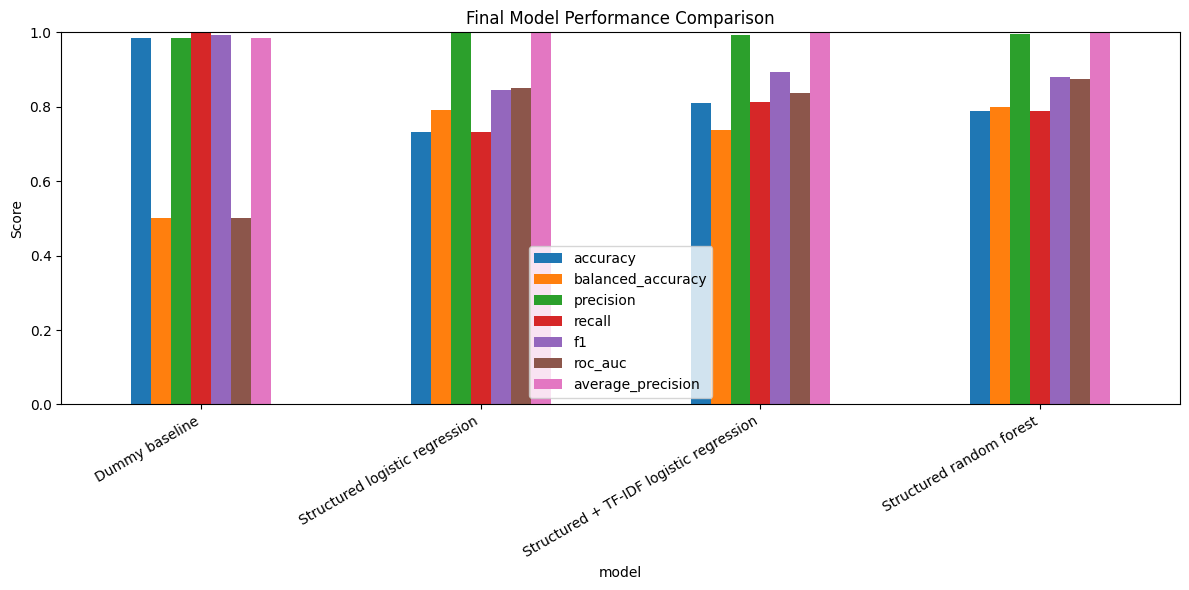

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/final_model_performance_comparison.png


In [9]:
# -------------------------------------------------------------------
# Visualize model performance comparison
# -------------------------------------------------------------------
if not model_performance.empty:
    metric_cols = [
        col for col in [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "average_precision"
        ]
        if col in model_performance.columns
    ]

    plot_df = model_performance.set_index("model")[metric_cols]

    plt.figure(figsize=(12, 6))
    plot_df.plot(kind="bar", figsize=(12, 6))
    plt.title("Final Model Performance Comparison")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    figure_path = OUTPUT_FIGURES / "final_model_performance_comparison.png"
    plt.savefig(figure_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved figure:", figure_path)
else:
    print("No model performance table available to plot.")

The chart compares four models across key performance metrics. The **Dummy baseline** shows very high accuracy, but this is misleading because it only predicts the majority timely-response class and has weak balanced accuracy and ROC-AUC.

Among the real models, the **Structured Random Forest** performs best overall for risk detection. It has the highest **balanced accuracy** and **ROC-AUC**, showing the strongest ability to distinguish between timely and non-timely complaints.

The **Structured + TF-IDF Logistic Regression** has the highest accuracy and F1-score among the predictive models, suggesting that narrative text improves overall classification performance. However, it does not outperform the random forest on balanced performance.

**Conclusion:** The **Structured Random Forest** is the best model for response-timeliness risk detection, while the TF-IDF model confirms that customer narratives add useful predictive value.


## Model Comparison Interpretation

The dummy baseline is included only as a reference point. In an imbalanced dataset, a dummy model can look strong by accuracy while having no ability to detect non-timely complaints. The preferred model should be selected using ROC-AUC, balanced accuracy, classwise metrics, and operational usefulness.


In [10]:
# -------------------------------------------------------------------
# Report-ready model comparison interpretation
# -------------------------------------------------------------------
model_comparison_interpretation = []

if not model_performance.empty:
    available_metrics = [col for col in ["accuracy", "balanced_accuracy", "f1", "roc_auc", "average_precision"] if col in model_performance.columns]
    ranked_by_auc = model_performance.sort_values("roc_auc", ascending=False) if "roc_auc" in model_performance.columns else model_performance.copy()

    for _, row in ranked_by_auc.iterrows():
        model_name = row["model"]
        if model_name == "Dummy baseline":
            message = "Reference model only; high accuracy is caused by the majority timely-response class."
        elif model_name == "Structured random forest":
            message = "Strongest balanced risk-detection candidate when ROC-AUC and balanced accuracy are prioritized."
        elif model_name == "Structured + TF-IDF logistic regression":
            message = "Useful evidence that narratives add value, especially for overall accuracy and F1-score."
        elif model_name == "Structured logistic regression":
            message = "Strong and explainable structured model; useful benchmark for governance and interpretation."
        else:
            message = "Predictive model included in comparison."

        model_comparison_interpretation.append({
            "model": model_name,
            **{metric: row.get(metric, np.nan) for metric in available_metrics},
            "business_interpretation": message
        })

model_comparison_interpretation = round_numeric_columns(pd.DataFrame(model_comparison_interpretation), 4)

if not model_comparison_interpretation.empty:
    save_table(model_comparison_interpretation, "final_model_comparison_interpretation.csv")
    display(model_comparison_interpretation)
else:
    print("Model performance table not available for interpretation.")


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_model_comparison_interpretation.csv


,model,accuracy,balanced_accuracy,f1,roc_auc,average_precision,business_interpretation
0,Structured random forest,0.7884,0.8000,0.8802,0.8748,0.9978,Strongest balanced risk-detection candidate wh...
1,Structured logistic regression,0.7333,0.7908,0.8440,0.8506,0.9974,Strong and explainable structured model; usefu...
2,Structured + TF-IDF logistic regression,0.8112,0.7384,0.8947,0.8357,0.9970,"Useful evidence that narratives add value, esp..."
3,Dummy baseline,0.9859,0.5000,0.9929,0.5000,0.9859,Reference model only; high accuracy is caused ...


### Brief Summary

The **Structured Random Forest** is the best final model for response-timeliness risk detection. It achieved the highest **ROC-AUC of 0.8748** and the highest **balanced accuracy of 0.8000**, making it the strongest model for distinguishing between timely and non-timely complaints.

The **Structured Logistic Regression** is also useful because it is more explainable and still performs strongly, with **ROC-AUC of 0.8506** and **balanced accuracy of 0.7908**.

The **Structured + TF-IDF Logistic Regression** achieved the highest F1-score among the real models, but its lower balanced accuracy and ROC-AUC suggest that narrative features improved overall classification more than balanced risk detection.

The **Dummy Baseline** should remain only as a reference model. Its accuracy is high because most complaints are timely, but its balanced accuracy and ROC-AUC of **0.5000** confirm that it does not provide meaningful predictive value.

### Suggested Full Business Interpretation Text

| Model                                   | Business interpretation                                                                                                                                   |
| --------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Structured random forest                | Strongest balanced risk-detection candidate with the best ROC-AUC and balanced accuracy. Recommended as the final model for operational complaint triage. |
| Structured logistic regression          | Strong and explainable structured model; useful for coefficient interpretation and business transparency.                                                 |
| Structured + TF-IDF logistic regression | Useful evidence that narratives add value, especially for overall accuracy and F1-score, but weaker than random forest for balanced risk detection.       |
| Dummy baseline                          | Reference model only; high accuracy is caused by class imbalance and does not indicate real predictive value.                                             |




## Step 2: Load the Processed Dataset

The processed dataset is loaded again so that model errors and subgroup performance can be interpreted in business terms.

In [11]:
# -------------------------------------------------------------------
# Load processed dataset
# -------------------------------------------------------------------
df = pd.read_csv(PROCESSED_FILE, low_memory=False)

print("Dataset loaded.")
print("Rows:", f"{df.shape[0]:,}")
print("Columns:", f"{df.shape[1]:,}")

df.head()

Dataset loaded.
Rows: 1,289,027
Columns: 25


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id,date_received_raw,date_sent_to_company_raw,year_received,month_received,quarter_received,timely_response_binary,has_narrative,narrative_length,received_to_sent_lag_days
0,2025-07-05 08:45:32+00:00,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Changes in loan terms during the application p...,I signed an initial disclosure for a XXXX mort...,Company believes the complaint is the result o...,"Your Favorite Lenders, Inc",OH,441XX,NaN,Web,2026-05-05 13:43:00+00:00,Closed with explanation,Yes,21636268,2025-07-05T08:45:32.000Z,2026-05-05T13:43:00.000Z,2025,2025-07,2025Q3,1,1,516,304.0
1,2025-07-11 03:39:40+00:00,"Payday loan, title loan, personal loan, or adv...",Payday loan,Charged fees or interest you didn't expect,NaN,I am filing a complaint against Integra Credit...,NaN,"Deinde Online Services, LLC",FL,33068,NaN,Web,2026-04-21 17:42:21+00:00,Closed with explanation,Yes,21447929,2025-07-11T03:39:40.000Z,2026-04-21T17:42:21.000Z,2025,2025-07,2025Q3,1,1,998,284.0
2,2025-08-11 18:59:48+00:00,Mortgage,Conventional home mortgage,Struggling to pay mortgage,Trying to communicate with the company to fix ...,NaN,NaN,"Del Toro Loan Servicing, Inc",CA,94552,Older American,Phone,2025-08-15 06:00:26+00:00,Closed with explanation,No,15198684,2025-08-11T18:59:48.000Z,2025-08-15T06:00:26.000Z,2025,2025-08,2025Q3,0,0,0,3.0
3,2025-08-17 01:15:29+00:00,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,"Dear all, My name is XXXX XXXX, my address is ...",Company disputes the facts presented in the co...,"RESCO, INC.",HI,96815,NaN,Web,2026-05-04 13:13:09+00:00,Closed with explanation,Yes,21848458,2025-08-17T01:15:29.000Z,2026-05-04T13:13:09.000Z,2025,2025-08,2025Q3,1,1,1805,260.0
4,2025-09-25 15:49:13+00:00,Mortgage,VA mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,NaN,NaN,"Mortgage Express, Inc.",GA,30662,Servicemember,Web,2026-04-30 15:44:57+00:00,Closed with explanation,Yes,21669790,2025-09-25T15:49:13.000Z,2026-04-30T15:44:57.000Z,2025,2025-09,2025Q3,1,0,0,216.0


In [12]:
# -------------------------------------------------------------------
# Basic preparation
# -------------------------------------------------------------------
for col in ["date_received", "date_sent_to_company"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

if "year_received" not in df.columns and "date_received" in df.columns:
    df["year_received"] = df["date_received"].dt.year

if "month_received" not in df.columns and "date_received" in df.columns:
    df["month_received"] = df["date_received"].dt.to_period("M").astype(str)

if "timely_response_binary" not in df.columns:
    df["timely_response_binary"] = (
        df["timely_response"]
        .astype(str)
        .str.lower()
        .str.strip()
        .map({"yes": 1, "no": 0})
    )

if "has_narrative" not in df.columns:
    df["has_narrative"] = df["consumer_complaint_narrative"].notna().astype(int)

if "narrative_length" not in df.columns:
    df["narrative_length"] = df["consumer_complaint_narrative"].fillna("").astype(str).str.len()

df["narrative_text"] = df["consumer_complaint_narrative"].fillna("").astype(str)

print("Preparation complete.")
print("Valid target records:", f"{df['timely_response_binary'].notna().sum():,}")

Preparation complete.
Valid target records: 1,289,027


## Step 3: Recreate the Modeling Sample

Notebook 04 used a controlled stratified sample for practical runtime. This notebook recreates the same sample settings so that saved models can be interpreted on the same test split.

In [13]:
# -------------------------------------------------------------------
# Modeling configuration
# -------------------------------------------------------------------
RANDOM_STATE = 42
MODEL_SAMPLE_SIZE = 150_000
TOP_N_COMPANIES = 50
TOP_N_STATES = 50

print("Random state:", RANDOM_STATE)
print("Model sample size:", MODEL_SAMPLE_SIZE)

Random state: 42
Model sample size: 150000


In [14]:
# -------------------------------------------------------------------
# Recreate modeling dataset
# -------------------------------------------------------------------
model_df = df.dropna(subset=["timely_response_binary"]).copy()

# Group high-cardinality company and state fields
if "company" in model_df.columns:
    top_companies = model_df["company"].value_counts().head(TOP_N_COMPANIES).index
    model_df["company_grouped"] = np.where(model_df["company"].isin(top_companies), model_df["company"], "Other")
else:
    model_df["company_grouped"] = "Unknown"

if "state" in model_df.columns:
    top_states = model_df["state"].value_counts().head(TOP_N_STATES).index
    model_df["state_grouped"] = np.where(model_df["state"].isin(top_states), model_df["state"], "Other")
else:
    model_df["state_grouped"] = "Unknown"

categorical_features = [
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "submitted_via",
    "state_grouped",
    "company_grouped",
    "tags",
    "year_received"
]

numeric_features = [
    "has_narrative",
    "narrative_length"
]

text_feature = "narrative_text"

categorical_features = [col for col in categorical_features if col in model_df.columns]
numeric_features = [col for col in numeric_features if col in model_df.columns]

required_model_cols = ["timely_response_binary"] + categorical_features + numeric_features + [text_feature]
model_df = model_df[required_model_cols].copy()

for col in categorical_features:
    model_df[col] = model_df[col].fillna("Unknown").astype(str)

for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce").fillna(0)

model_df[text_feature] = model_df[text_feature].fillna("").astype(str)
model_df["timely_response_binary"] = model_df["timely_response_binary"].astype(int)

# Same stratified sample setting as Notebook 04
if len(model_df) > MODEL_SAMPLE_SIZE:
    model_df, _ = train_test_split(
        model_df,
        train_size=MODEL_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=model_df["timely_response_binary"]
    )

print("Modeling dataset shape:", model_df.shape)
print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)
print("Text feature:", text_feature)

model_df.head()

Modeling dataset shape: (150000, 13)
Categorical features: ['product', 'sub_product', 'issue', 'sub_issue', 'submitted_via', 'state_grouped', 'company_grouped', 'tags', 'year_received']
Numeric features: ['has_narrative', 'narrative_length']
Text feature: narrative_text


,timely_response_binary,product,sub_product,issue,sub_issue,submitted_via,state_grouped,company_grouped,tags,year_received,has_narrative,narrative_length,narrative_text
1062841,1,Credit card or prepaid card,General-purpose credit card or charge card,Problem when making payments,Problem during payment process,Phone,FL,"BANK OF AMERICA, NATIONAL ASSOCIATION",Unknown,2021,0,0,
830479,1,Mortgage,Conventional home mortgage,Struggling to pay mortgage,Unknown,Web,IN,Mr. Cooper Group Inc.,Unknown,2019,0,0,
1240541,1,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,Web,NY,CAPITAL ONE FINANCIAL CORPORATION,Unknown,2022,0,0,
171344,1,Mortgage,FHA mortgage,Trouble during payment process,Paying off the loan,Web,TN,PNC Bank N.A.,Unknown,2024,0,0,
585155,1,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,Confusing or missing disclosures,Unknown,Web,OH,Chime Financial Inc,Unknown,2025,1,987,Chime bank drafted a total of XXXX dollars fro...


In [15]:
# -------------------------------------------------------------------
# Train-test split
# -------------------------------------------------------------------
X = model_df[categorical_features + numeric_features + [text_feature]].copy()
y = model_df["timely_response_binary"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

structured_features = categorical_features + numeric_features

X_test_structured = X_test[structured_features].copy()
X_test_text = X_test[categorical_features + numeric_features + [text_feature]].copy()

print("Test rows:", f"{len(X_test):,}")
display(y_test.value_counts(normalize=True).reset_index())

Test rows: 45,000


,timely_response_binary,proportion
0,1,0.985933
1,0,0.014067


## Target Imbalance and Evaluation Policy

The primary target for response-timeliness modeling is highly imbalanced. Therefore, final interpretation should not rely on accuracy alone. The business goal is not only to classify timely complaints, but also to identify rare non-timely complaints early enough for review and escalation.

This section creates a final target-distribution table and a short evaluation-policy table for the report appendix.


In [16]:
# -------------------------------------------------------------------
# Target distribution and evaluation policy
# -------------------------------------------------------------------
target_distribution = (
    y_test.value_counts()
    .rename_axis("timely_response_binary")
    .reset_index(name="count")
)
target_distribution["label"] = target_distribution["timely_response_binary"].map({0: "Non-timely", 1: "Timely"})
target_distribution["percent"] = (target_distribution["count"] / target_distribution["count"].sum() * 100).round(2)
target_distribution = target_distribution[["timely_response_binary", "label", "count", "percent"]]

save_table(target_distribution, "final_test_target_distribution.csv")
display(target_distribution)

evaluation_policy = pd.DataFrame([
    {
        "metric": "Accuracy",
        "interpretation": "Useful as a general measure, but misleading when most complaints are timely.",
        "business_use": "Do not use as the primary model-selection metric."
    },
    {
        "metric": "Balanced accuracy",
        "interpretation": "Gives equal weight to timely and non-timely classes.",
        "business_use": "Use to judge whether the model works across both classes."
    },
    {
        "metric": "ROC-AUC",
        "interpretation": "Measures ranking and separation ability across thresholds.",
        "business_use": "Use as the primary selection metric for risk-ranking models."
    },
    {
        "metric": "Non-timely recall",
        "interpretation": "Shows how many delayed-response risk cases are captured.",
        "business_use": "Important for early-warning and escalation use cases."
    },
    {
        "metric": "Non-timely precision",
        "interpretation": "Shows how many flagged risk cases are truly non-timely.",
        "business_use": "Important for managing analyst workload and false alerts."
    },
    {
        "metric": "Average precision / PR-AUC",
        "interpretation": "Useful for rare-class detection when one class is uncommon.",
        "business_use": "Use together with threshold analysis and classwise metrics."
    }
])

save_table(evaluation_policy, "final_model_evaluation_policy.csv")
display(evaluation_policy)


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_test_target_distribution.csv


,timely_response_binary,label,count,percent
0,1,Timely,44367,98.59
1,0,Non-timely,633,1.41


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_model_evaluation_policy.csv


,metric,interpretation,business_use
0,Accuracy,"Useful as a general measure, but misleading wh...",Do not use as the primary model-selection metric.
1,Balanced accuracy,Gives equal weight to timely and non-timely cl...,Use to judge whether the model works across bo...
2,ROC-AUC,Measures ranking and separation ability across...,Use as the primary selection metric for risk-r...
3,Non-timely recall,Shows how many delayed-response risk cases are...,Important for early-warning and escalation use...
4,Non-timely precision,Shows how many flagged risk cases are truly no...,Important for managing analyst workload and fa...
5,Average precision / PR-AUC,Useful for rare-class detection when one class...,Use together with threshold analysis and class...


## Step 4: Load Trained Models

The notebook loads the models saved by Notebook 04. If a model file is missing, run Notebook 04 first.

In [17]:
# -------------------------------------------------------------------
# Load saved models
# -------------------------------------------------------------------
model_files = {
    "Dummy baseline": OUTPUT_MODELS / "model_baseline_dummy.pkl",
    "Structured logistic regression": OUTPUT_MODELS / "model_structured_logistic.pkl",
    "Structured + TF-IDF logistic regression": OUTPUT_MODELS / "model_structured_text_logistic.pkl",
    "Structured random forest": OUTPUT_MODELS / "model_structured_random_forest.pkl"
}

loaded_models = {}

for model_name, model_path in model_files.items():
    if model_path.exists():
        loaded_models[model_name] = joblib.load(model_path)
        print(f"Loaded: {model_name}")
    else:
        print(f"Missing model file: {model_name} -> {model_path}")

print("Models loaded:", list(loaded_models.keys()))

Loaded: Dummy baseline
Loaded: Structured logistic regression
Loaded: Structured + TF-IDF logistic regression
Loaded: Structured random forest
Models loaded: ['Dummy baseline', 'Structured logistic regression', 'Structured + TF-IDF logistic regression', 'Structured random forest']


## Step 5: Select the Best Available Model

The best model is selected using the previous ROC-AUC ranking if available. If the prior summary is unavailable, the notebook uses the structured + TF-IDF model if it exists.

In [18]:
# -------------------------------------------------------------------
# Select best model
# -------------------------------------------------------------------
# Primary rule: use the best-model summary generated in Notebook 04.
# Secondary rule: select the highest ROC-AUC model from the performance table.
# Final fallback: use the strongest available structured model.

best_model_name = None

if not best_model_summary.empty and "best_model" in best_model_summary.columns:
    candidate = best_model_summary.loc[0, "best_model"]
    if candidate in loaded_models:
        best_model_name = candidate
        print("Best model selected from Notebook 04 summary:", best_model_name)

if best_model_name is None and not model_performance.empty and "roc_auc" in model_performance.columns:
    ranked_models = (
        model_performance
        .dropna(subset=["roc_auc"])
        .sort_values("roc_auc", ascending=False)
    )
    for candidate in ranked_models["model"]:
        if candidate in loaded_models:
            best_model_name = candidate
            print("Best model selected by ROC-AUC from performance table:", best_model_name)
            break

if best_model_name is None:
    preferred_order = [
        "Structured random forest",
        "Structured logistic regression",
        "Structured + TF-IDF logistic regression",
        "Dummy baseline"
    ]

    for name in preferred_order:
        if name in loaded_models:
            best_model_name = name
            print("Best model selected by fallback order:", best_model_name)
            break

if best_model_name is None:
    raise FileNotFoundError(
        "No trained model files were found. Please run 04_model_training.ipynb first."
    )

best_model = loaded_models[best_model_name]
print("Selected best model:", best_model_name)


Best model selected from Notebook 04 summary: Structured random forest
Selected best model: Structured random forest


In [19]:
# -------------------------------------------------------------------
# Prepare correct test matrix for selected model
# -------------------------------------------------------------------
def get_test_matrix_for_model(model_name):
    if model_name in ["Structured logistic regression", "Structured random forest"]:
        return X_test_structured
    elif model_name == "Structured + TF-IDF logistic regression":
        return X_test_text
    else:
        return X_test

X_test_best = get_test_matrix_for_model(best_model_name)

print("Best model test matrix shape:", X_test_best.shape)

Best model test matrix shape: (45000, 11)


## Step 6: Best Model Evaluation

This section evaluates the selected model on the test set and saves the results.

In [20]:
# -------------------------------------------------------------------
# Evaluate selected best model
# -------------------------------------------------------------------
y_pred = best_model.predict(X_test_best)

if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test_best)[:, 1]
else:
    y_score = y_pred

best_metrics = pd.DataFrame([{
    "model": best_model_name,
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_score),
    "average_precision": average_precision_score(y_test, y_score)
}])

for col in best_metrics.columns:
    if col != "model":
        best_metrics[col] = best_metrics[col].round(4)

best_metrics_path = OUTPUT_TABLES / "final_best_model_evaluation.csv"
best_metrics.to_csv(best_metrics_path, index=False)

print("Saved table:", best_metrics_path)
best_metrics

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_best_model_evaluation.csv


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Structured random forest,0.7884,0.8,0.9966,0.7881,0.8802,0.8748,0.9978


## Best Model Classwise Performance

The business risk is the rare **non-timely response** class. Because the model was trained with `1 = timely response`, this section also evaluates performance from the risk perspective using `1 = non-timely response`.


In [21]:
# -------------------------------------------------------------------
# Classwise performance for timely and non-timely classes
# -------------------------------------------------------------------
class_report_dict = classification_report(
    y_test,
    y_pred,
    target_names=["Non-timely", "Timely"],
    output_dict=True,
    zero_division=0
)

class_report = pd.DataFrame(class_report_dict).T.reset_index().rename(columns={"index": "class"})
class_report = round_numeric_columns(class_report, 4)
save_table(class_report, "final_best_model_classification_report.csv")
display(class_report)

# Risk perspective: 1 means non-timely risk.
y_test_non_timely = 1 - y_test
risk_score_non_timely = 1 - y_score
risk_pred_default = (risk_score_non_timely >= 0.50).astype(int)

risk_metrics = pd.DataFrame([{
    "model": best_model_name,
    "risk_target": "Non-timely response",
    "accuracy": accuracy_score(y_test_non_timely, risk_pred_default),
    "balanced_accuracy": balanced_accuracy_score(y_test_non_timely, risk_pred_default),
    "precision_non_timely": precision_score(y_test_non_timely, risk_pred_default, zero_division=0),
    "recall_non_timely": recall_score(y_test_non_timely, risk_pred_default, zero_division=0),
    "f1_non_timely": f1_score(y_test_non_timely, risk_pred_default, zero_division=0),
    "roc_auc_non_timely_risk": roc_auc_score(y_test_non_timely, risk_score_non_timely),
    "average_precision_non_timely_risk": average_precision_score(y_test_non_timely, risk_score_non_timely)
}])

risk_metrics = round_numeric_columns(risk_metrics, 4)
save_table(risk_metrics, "final_best_model_non_timely_risk_metrics.csv")
display(risk_metrics)


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_best_model_classification_report.csv


,class,precision,recall,f1-score,support
0,Non-timely,0.0518,0.8120,0.0974,633.0000
1,Timely,0.9966,0.7881,0.8802,44367.0000
2,accuracy,0.7884,0.7884,0.7884,0.7884
3,macro avg,0.5242,0.8000,0.4888,45000.0000
4,weighted avg,0.9833,0.7884,0.8691,45000.0000


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_best_model_non_timely_risk_metrics.csv


,model,risk_target,accuracy,balanced_accuracy,precision_non_timely,recall_non_timely,f1_non_timely,roc_auc_non_timely_risk,average_precision_non_timely_risk
0,Structured random forest,Non-timely response,0.7884,0.8,0.0518,0.812,0.0974,0.8748,0.1181


### Final Best Model: Non-Timely Risk Interpretation

The **Structured Random Forest** performs well as an early-warning model for non-timely complaint response risk. The most important result is the **non-timely recall of 0.8120**, meaning the model identifies about **81.2% of actual non-timely complaints**.

However, the **non-timely precision is low at 0.0518**. This means that many complaints flagged as non-timely risk will still turn out to be timely. In business terms, the model is better at **catching risk cases** than at producing a small, highly accurate alert list.

| Metric                                |  Value | Meaning                                                        |
| ------------------------------------- | -----: | -------------------------------------------------------------- |
| Accuracy                              | 0.7884 | Good overall performance                                       |
| Balanced accuracy                     | 0.8000 | Strong performance across both classes                         |
| Non-timely precision                  | 0.0518 | Many flagged cases are false positives                         |
| Non-timely recall                     | 0.8120 | Strong ability to catch delayed-response risk                  |
| Non-timely F1-score                   | 0.0974 | Low because precision remains weak                             |
| ROC-AUC for non-timely risk           | 0.8748 | Strong ranking ability                                         |
| Average precision for non-timely risk | 0.1181 | Better than baseline, but still limited due to class imbalance |

### Business Interpretation

This model is useful for **risk-based complaint triage**, not automatic decision-making. It can help identify a larger pool of complaints that may need closer monitoring, escalation review, or proactive follow-up.

Because non-timely complaints are rare, low precision is expected. The model is intentionally catching many possible risk cases, but this creates a review workload. Therefore, threshold tuning is important. A higher risk threshold can reduce false alerts, while a lower threshold can catch more delayed cases.




Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_best_model_confusion_matrix.csv


,Predicted 0: Not timely,Predicted 1: Timely
Actual 0: Not timely,514,119
Actual 1: Timely,9403,34964


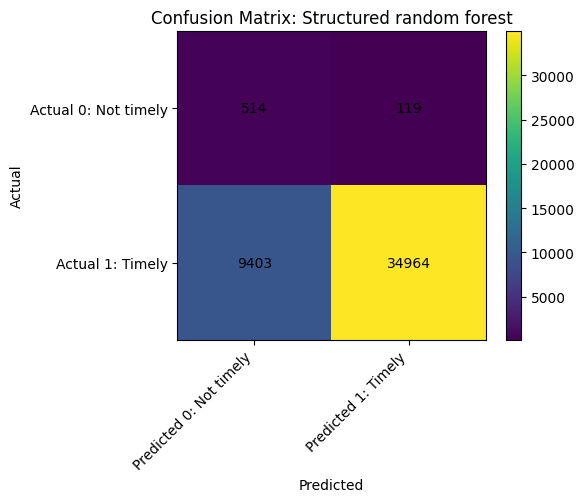

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/final_best_model_confusion_matrix.png


In [22]:
# -------------------------------------------------------------------
# Confusion matrix for best model
# -------------------------------------------------------------------
best_cm = confusion_matrix(y_test, y_pred)

best_cm_df = pd.DataFrame(
    best_cm,
    index=["Actual 0: Not timely", "Actual 1: Timely"],
    columns=["Predicted 0: Not timely", "Predicted 1: Timely"]
)

best_cm_path = OUTPUT_TABLES / "final_best_model_confusion_matrix.csv"
best_cm_df.reset_index().rename(columns={"index": "actual"}).to_csv(best_cm_path, index=False)

print("Saved table:", best_cm_path)
display(best_cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(best_cm_df.values, interpolation="nearest")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.colorbar()
tick_marks = np.arange(len(best_cm_df.columns))
plt.xticks(tick_marks, best_cm_df.columns, rotation=45, ha="right")
plt.yticks(tick_marks, best_cm_df.index)

for i in range(best_cm_df.shape[0]):
    for j in range(best_cm_df.shape[1]):
        plt.text(j, i, best_cm_df.values[i, j], ha="center", va="center")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "final_best_model_confusion_matrix.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

## Step 7: ROC and Precision-Recall Curves

ROC-AUC is useful for overall ranking ability. Precision-recall curves are especially useful when the target class is imbalanced.

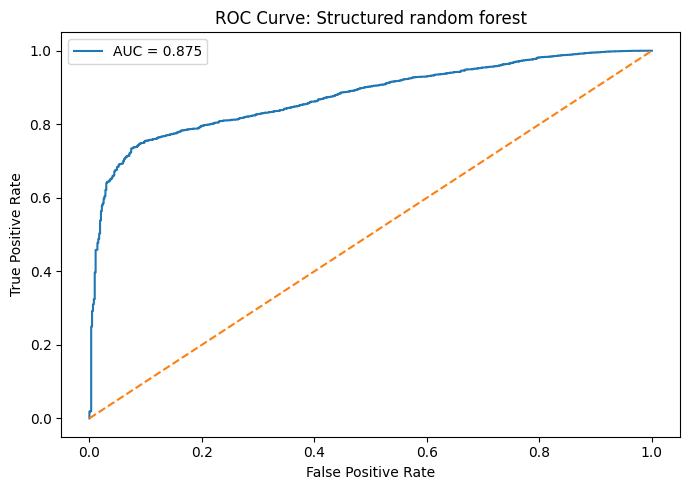

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_best_model_roc_curve_points.csv
Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/final_best_model_roc_curve.png


In [23]:
# -------------------------------------------------------------------
# ROC curve
# -------------------------------------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_score)
roc_auc_value = roc_auc_score(y_test, y_score)

roc_curve_df = pd.DataFrame({
    "false_positive_rate": fpr,
    "true_positive_rate": tpr,
    "threshold": roc_thresholds
})

roc_curve_path = OUTPUT_TABLES / "final_best_model_roc_curve_points.csv"
roc_curve_df.to_csv(roc_curve_path, index=False)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curve: {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "final_best_model_roc_curve.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved table:", roc_curve_path)
print("Saved figure:", figure_path)

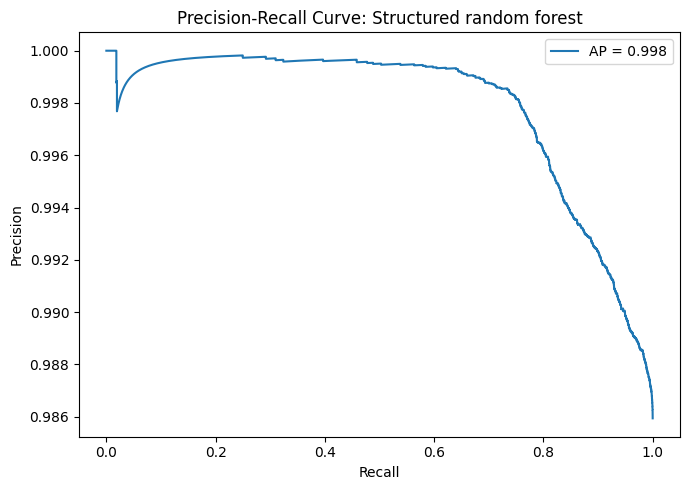

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_best_model_precision_recall_curve_points.csv
Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/final_best_model_precision_recall_curve.png


In [24]:
# -------------------------------------------------------------------
# Precision-recall curve
# -------------------------------------------------------------------
precision_values, recall_values, pr_thresholds = precision_recall_curve(y_test, y_score)
average_precision_value = average_precision_score(y_test, y_score)

pr_curve_df = pd.DataFrame({
    "precision": precision_values,
    "recall": recall_values,
    "threshold": list(pr_thresholds) + [np.nan]
})

pr_curve_path = OUTPUT_TABLES / "final_best_model_precision_recall_curve_points.csv"
pr_curve_df.to_csv(pr_curve_path, index=False)

plt.figure(figsize=(7, 5))
plt.plot(recall_values, precision_values, label=f"AP = {average_precision_value:.3f}")
plt.title(f"Precision-Recall Curve: {best_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "final_best_model_precision_recall_curve.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved table:", pr_curve_path)
print("Saved figure:", figure_path)

## Step 8: Threshold Analysis

The default classification threshold is 0.50. In complaint operations, a bank may choose a lower or higher threshold depending on the goal.

For example:

- If the goal is to catch more at-risk complaints, increase recall.
- If the goal is to avoid too many false alerts, increase precision.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_threshold_analysis.csv


,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,0.10,0.9861,0.5071,0.9861,1.0000,0.9930
1,0.15,0.9856,0.5263,0.9867,0.9989,0.9928
2,0.20,0.9816,0.5538,0.9874,0.9939,0.9907
3,0.25,0.9599,0.6059,0.9890,0.9701,0.9795
4,0.30,0.9364,0.6423,0.9901,0.9449,0.9670
5,0.35,0.9044,0.6915,0.9918,0.9106,0.9494
6,0.40,0.8492,0.7374,0.9937,0.8524,0.9177
7,0.45,0.8185,0.7709,0.9952,0.8199,0.8991
8,0.50,0.7884,0.8000,0.9966,0.7881,0.8802
9,0.55,0.7609,0.8227,0.9979,0.7591,0.8622


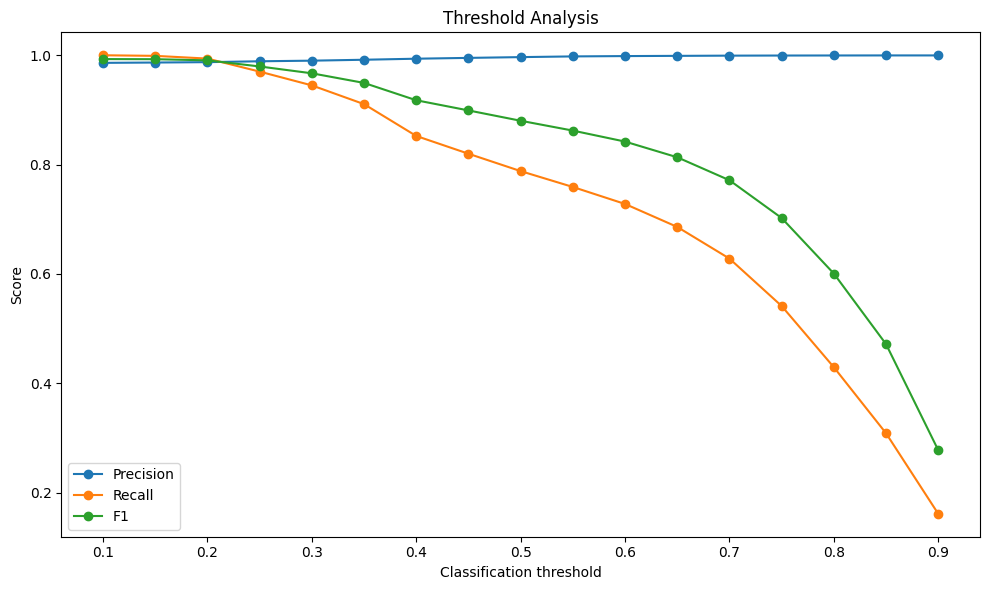

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/final_threshold_analysis.png


In [25]:
# -------------------------------------------------------------------
# Threshold analysis
# -------------------------------------------------------------------
thresholds_to_test = np.arange(0.10, 0.91, 0.05)

threshold_rows = []

for threshold in thresholds_to_test:
    threshold_pred = (y_score >= threshold).astype(int)

    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "accuracy": accuracy_score(y_test, threshold_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, threshold_pred),
        "precision": precision_score(y_test, threshold_pred, zero_division=0),
        "recall": recall_score(y_test, threshold_pred, zero_division=0),
        "f1": f1_score(y_test, threshold_pred, zero_division=0)
    })

threshold_analysis = pd.DataFrame(threshold_rows)

for col in ["accuracy", "balanced_accuracy", "precision", "recall", "f1"]:
    threshold_analysis[col] = threshold_analysis[col].round(4)

threshold_path = OUTPUT_TABLES / "final_threshold_analysis.csv"
threshold_analysis.to_csv(threshold_path, index=False)

print("Saved table:", threshold_path)
display(threshold_analysis)

plt.figure(figsize=(10, 6))
plt.plot(threshold_analysis["threshold"], threshold_analysis["precision"], marker="o", label="Precision")
plt.plot(threshold_analysis["threshold"], threshold_analysis["recall"], marker="o", label="Recall")
plt.plot(threshold_analysis["threshold"], threshold_analysis["f1"], marker="o", label="F1")
plt.title("Threshold Analysis")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "final_threshold_analysis.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

### Threshold Analysis

The threshold analysis shows how the random forest model behaves when the classification cutoff is changed. Instead of using only the default threshold of **0.50**, the analysis tests multiple thresholds from **0.10 to 0.90** to understand how precision, recall, F1-score, accuracy, and balanced accuracy change.

At lower thresholds, the model predicts more complaints as **timely**. This results in very high recall because the model captures almost all timely-response cases. For example, at a threshold of **0.10**, recall is **1.0000**, meaning nearly all actual timely complaints are identified. However, balanced accuracy is only **0.5071**, which is close to random performance when both classes are treated equally. This shows that very low thresholds do not help the model distinguish well between timely and non-timely complaints.

As the threshold increases, the model becomes more selective when predicting a complaint as timely. Precision remains very high across all thresholds, increasing from **0.9861** at threshold **0.10** to **0.9997** at threshold **0.90**. This means that when the model predicts timely response, it is usually correct. However, recall drops sharply as the threshold rises because the model becomes more conservative and starts missing more actual timely cases.

The most useful part of the analysis is the balanced accuracy trend. Balanced accuracy improves from **0.5071** at threshold **0.10** to a peak of **0.8269** at threshold **0.60**. This suggests that the default threshold of **0.50** is good, but not necessarily optimal. At threshold **0.50**, the model achieves **0.7884 accuracy**, **0.8000 balanced accuracy**, and **0.8802 F1-score**. At threshold **0.60**, accuracy decreases to **0.7308**, but balanced accuracy improves to **0.8269**. This means threshold **0.60** provides a better balance between the timely and non-timely classes.

The F1-score is highest at lower thresholds because the timely-response class dominates the dataset. At threshold **0.10**, F1-score is **0.9930**, but this does not mean the model is best for risk detection. Because the dataset is highly imbalanced, high F1-score for the timely class can hide weak performance on the rare non-timely class. Therefore, balanced accuracy is more useful for selecting an operational threshold.

From a business perspective, threshold selection depends on the purpose of the model. If the goal is to maximise correct identification of timely responses, a lower threshold may look attractive because recall and F1-score are high. However, if the goal is to support **risk detection for non-timely complaints**, then a threshold around **0.55 to 0.60** is more useful because it improves balanced accuracy and gives fairer attention to both classes.

Very high thresholds, such as **0.80 to 0.90**, are not ideal for general operational use. Although precision remains almost perfect, recall falls heavily. At threshold **0.90**, recall drops to **0.1613** and F1-score drops to **0.2777**. This means the model becomes too strict and misses many actual timely cases. Such a high threshold may only be useful in a narrow setting where the business wants only the most confident timely predictions.

Overall, the threshold analysis shows that the model should not automatically rely on the default **0.50** cutoff. The best threshold depends on the business objective. For balanced complaint-risk monitoring, threshold **0.60** appears stronger because it gives the highest balanced accuracy. For general classification, threshold **0.50** remains acceptable. For operational deployment, the final threshold should be selected based on review capacity, tolerance for false alerts, and the cost of missing non-timely complaints.


## Non-Timely Risk Threshold Analysis

The prior threshold table evaluates the probability of the **timely** class. For operations, the more useful view is the probability of **non-timely risk**. This section tests risk thresholds using:

`non-timely risk score = 1 - predicted probability of timely response`

A high threshold creates fewer alerts and higher precision. A low threshold captures more delayed-risk cases but increases false alerts.


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_non_timely_risk_threshold_analysis.csv


,risk_threshold,flagged_records,flagged_percent,precision_non_timely,recall_non_timely,f1_non_timely,balanced_accuracy
0,0.10,37843,84.10,0.0167,0.9968,0.0328,0.5791
1,0.15,31304,69.56,0.0201,0.9937,0.0394,0.6511
2,0.20,25944,57.65,0.0241,0.9889,0.0471,0.7091
3,0.25,20967,46.59,0.0296,0.9795,0.0574,0.7604
4,0.30,17115,38.03,0.0359,0.9700,0.0692,0.7990
5,0.35,14530,32.29,0.0413,0.9479,0.0791,0.8169
6,0.40,12652,28.12,0.0463,0.9258,0.0882,0.8269
7,0.45,11250,25.00,0.0499,0.8863,0.0944,0.8227
8,0.50,9917,22.04,0.0518,0.8120,0.0974,0.8000
9,0.55,8449,18.78,0.0541,0.7220,0.1006,0.7709


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_recommended_non_timely_risk_threshold.csv


,risk_threshold,flagged_records,flagged_percent,precision_non_timely,recall_non_timely,f1_non_timely,balanced_accuracy,selection_reason
14,0.8,341,0.76,0.2111,0.1137,0.1478,0.5538,Highest non-timely F1-score among tested thres...


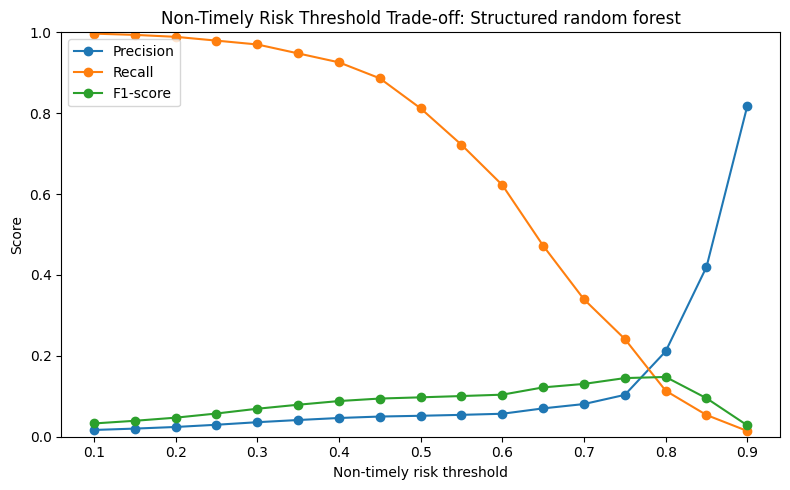

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/final_non_timely_risk_threshold_analysis.png


In [26]:
# -------------------------------------------------------------------
# Non-timely risk threshold analysis
# -------------------------------------------------------------------
risk_thresholds_to_test = np.arange(0.10, 0.91, 0.05)
risk_threshold_rows = []

total_test_records = len(y_test_non_timely)

for threshold in risk_thresholds_to_test:
    risk_pred = (risk_score_non_timely >= threshold).astype(int)
    flagged_records = int(risk_pred.sum())

    risk_threshold_rows.append({
        "risk_threshold": round(float(threshold), 2),
        "flagged_records": flagged_records,
        "flagged_percent": round(flagged_records / total_test_records * 100, 2),
        "precision_non_timely": precision_score(y_test_non_timely, risk_pred, zero_division=0),
        "recall_non_timely": recall_score(y_test_non_timely, risk_pred, zero_division=0),
        "f1_non_timely": f1_score(y_test_non_timely, risk_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test_non_timely, risk_pred)
    })

non_timely_threshold_analysis = round_numeric_columns(pd.DataFrame(risk_threshold_rows), 4)
non_timely_threshold_analysis = non_timely_threshold_analysis.sort_values("risk_threshold")

save_table(non_timely_threshold_analysis, "final_non_timely_risk_threshold_analysis.csv")
display(non_timely_threshold_analysis)

best_risk_threshold = (
    non_timely_threshold_analysis
    .sort_values(["f1_non_timely", "precision_non_timely"], ascending=False)
    .head(1)
    .copy()
)
best_risk_threshold["selection_reason"] = "Highest non-timely F1-score among tested thresholds"

save_table(best_risk_threshold, "final_recommended_non_timely_risk_threshold.csv")
display(best_risk_threshold)

plt.figure(figsize=(8, 5))
plt.plot(non_timely_threshold_analysis["risk_threshold"], non_timely_threshold_analysis["precision_non_timely"], marker="o", label="Precision")
plt.plot(non_timely_threshold_analysis["risk_threshold"], non_timely_threshold_analysis["recall_non_timely"], marker="o", label="Recall")
plt.plot(non_timely_threshold_analysis["risk_threshold"], non_timely_threshold_analysis["f1_non_timely"], marker="o", label="F1-score")
plt.title(f"Non-Timely Risk Threshold Trade-off: {best_model_name}")
plt.xlabel("Non-timely risk threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

risk_threshold_fig = OUTPUT_FIGURES / "final_non_timely_risk_threshold_analysis.png"
plt.savefig(risk_threshold_fig, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", risk_threshold_fig)


### Non-Timely Risk Threshold Trade-Off

This threshold analysis focuses on the model’s ability to identify **non-timely response risk**, where the positive risk event is:

```text
Non-timely response = risk case
```

This is different from the earlier general classification threshold, which focused mainly on predicting timely responses. In this analysis, the threshold controls how strict the model is when deciding whether a complaint should be flagged as **non-timely risk**.

At very low thresholds, such as **0.10 to 0.30**, the model flags a very large share of complaints as possible non-timely risk. For example, at threshold **0.10**, the model flags **84.10%** of all test records. This gives extremely high recall of **99.68%**, meaning the model catches almost every actual non-timely complaint. However, precision is only **1.67%**, meaning most flagged complaints are false alerts. This threshold is useful only when the business wants maximum coverage and has a very large review capacity.

As the threshold increases, the model becomes more selective. The number of flagged records decreases, precision improves, and recall decreases. This is the normal trade-off in risk detection. At threshold **0.50**, the model flags **9,917 complaints**, or **22.04%** of the test set. It captures **81.20%** of actual non-timely complaints, with precision of **5.18%**. This means the model catches most risk cases, but the review team would still need to investigate many false alerts.

The best **balanced accuracy** appears at threshold **0.40**, with a score of **0.8269**. At this point, the model flags **12,652 records** or **28.12%** of the test set. It achieves **92.58% recall**, meaning it catches most non-timely cases, but precision remains low at **4.63%**. This threshold is useful if the organization wants broad early-warning coverage and is willing to review a larger number of complaints.

The best **non-timely F1-score** appears at threshold **0.80**, with an F1-score of **0.1478**. At this threshold, the model flags only **341 records**, or **0.76%** of the test set. Precision increases to **21.11%**, which is much stronger than the overall non-timely base rate of about **1.41%**. However, recall falls to only **11.37%**, meaning the model misses most actual non-timely complaints. This threshold is useful for creating a small, high-confidence review queue, but it is not ideal if the goal is to catch most delayed-response risks.

A simple way to interpret the threshold options is:

|     Threshold | Business Meaning                                                                                |
| ------------: | ----------------------------------------------------------------------------------------------- |
|      **0.40** | Broad early-warning threshold; catches most non-timely cases but creates many alerts            |
|      **0.50** | Balanced default option; captures many risk cases with a manageable but still large review pool |
| **0.60–0.70** | More selective review queue; fewer alerts but more missed non-timely cases                      |
|      **0.80** | High-confidence alert threshold; best F1-score and stronger precision, but low recall           |
|      **0.90** | Very strict threshold; very few alerts, high precision, but misses almost all risk cases        |

The selected threshold of **0.80** is reasonable if the objective is to produce a **small, high-confidence risk queue**. It flags fewer than 1% of records and increases non-timely precision to **21.11%**, which is much better than random selection. However, it should be clearly described as a **high-confidence threshold**, not a general risk-detection threshold, because it captures only **11.37%** of actual non-timely complaints.

For operational use, the best threshold depends on the complaint team’s capacity and risk tolerance. If the team can review many cases and wants to avoid missing delayed complaints, a lower threshold such as **0.40 or 0.50** is better. If the team can only review a small number of cases and wants a more concentrated alert list, **0.75 or 0.80** is better.

Overall, this analysis shows that the random forest model is useful for prioritization, but threshold selection must be treated as a business decision. The model should not automatically use a single cutoff without considering the cost of missed non-timely complaints, the cost of false alerts, and the available capacity for human review.


## Step 9: Error Analysis

This section labels each test record as:

- True Positive
- True Negative
- False Positive
- False Negative

This helps identify where the model performs well and where it struggles.

In [27]:
# -------------------------------------------------------------------
# Create error analysis dataframe
# -------------------------------------------------------------------
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["predicted"] = y_pred
error_df["predicted_probability_timely"] = y_score

def classify_error(row):
    if row["actual"] == 1 and row["predicted"] == 1:
        return "True Positive"
    elif row["actual"] == 0 and row["predicted"] == 0:
        return "True Negative"
    elif row["actual"] == 0 and row["predicted"] == 1:
        return "False Positive"
    elif row["actual"] == 1 and row["predicted"] == 0:
        return "False Negative"
    else:
        return "Unknown"

error_df["prediction_result"] = error_df.apply(classify_error, axis=1)

error_summary = error_df["prediction_result"].value_counts().reset_index()
error_summary.columns = ["prediction_result", "count"]
error_summary["percent"] = (error_summary["count"] / error_summary["count"].sum() * 100).round(2)

error_summary_path = OUTPUT_TABLES / "final_error_summary.csv"
error_summary.to_csv(error_summary_path, index=False)

print("Saved table:", error_summary_path)
error_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_error_summary.csv


,prediction_result,count,percent
0,True Positive,34964,77.70
1,False Negative,9403,20.90
2,True Negative,514,1.14
3,False Positive,119,0.26


### Prediction Result Analysis

This table explains how the **Structured Random Forest** classified the 45,000 test records at the selected/default threshold.

| Prediction result |  Count | Percent | Meaning                                                         |
| ----------------- | -----: | ------: | --------------------------------------------------------------- |
| True Positive     | 34,964 |  77.70% | Actual timely complaints correctly predicted as timely          |
| False Negative    |  9,403 |  20.90% | Actual timely complaints predicted as non-timely risk           |
| True Negative     |    514 |   1.14% | Actual non-timely complaints correctly identified as non-timely |
| False Positive    |    119 |   0.26% | Actual non-timely complaints incorrectly predicted as timely    |

### Main Interpretation

The model correctly classified a large share of timely complaints. The **34,964 true positives** show that the model is strong at recognizing normal timely-response cases. This supports the high precision for the timely class.

The most important business value is in the **true negatives**. The model correctly identified **514 non-timely complaints**, which is important because non-timely cases are rare but operationally significant. Since there were **633 actual non-timely complaints** in the test set, the model captured:

```text
514 / 633 = 81.20%
```

This confirms the strong **non-timely recall of 0.8120**.

However, the model also produced **9,403 false negatives** from the timely-response perspective. In business terms, these are complaints that were actually timely but were flagged as possible non-timely risk. This creates a large review workload. These cases explain why non-timely precision is low, even though non-timely recall is strong.

The **119 false positives** are more serious from a risk perspective because these are actual non-timely complaints that the model missed. However, this number is relatively small compared with the 633 total non-timely cases. This means the model misses only about **18.80%** of actual non-timely complaints.

### Business Meaning

The model is useful as an **early-warning triage tool**. It is good at catching most delayed-response risks, but it also flags many complaints that may not actually become delayed. This is acceptable if the business goal is to avoid missing risky complaints, but it requires human review capacity.

The model should not be used for automatic decisions. It should be used to create a risk queue where complaint teams can review, prioritize, and escalate cases based on available capacity.

### Strongest Observation

The model captured **514 out of 633 actual non-timely complaints**, which is a strong result for a rare-risk detection problem. The trade-off is that it also flagged many timely cases as risky, so threshold tuning is needed to control the size of the review queue.


In [28]:
# -------------------------------------------------------------------
# Error rate by category helper
# -------------------------------------------------------------------
def error_rate_by_group(dataframe, group_col, min_records=100):
    if group_col not in dataframe.columns:
        return pd.DataFrame()

    grouped = (
        dataframe
        .groupby(group_col, dropna=False)
        .agg(
            total_records=("actual", "size"),
            false_positive_count=("prediction_result", lambda x: (x == "False Positive").sum()),
            false_negative_count=("prediction_result", lambda x: (x == "False Negative").sum()),
            error_count=("prediction_result", lambda x: x.isin(["False Positive", "False Negative"]).sum()),
            average_predicted_probability=("predicted_probability_timely", "mean"),
            actual_timely_rate=("actual", "mean"),
            predicted_timely_rate=("predicted", "mean")
        )
        .reset_index()
    )

    grouped["error_rate_percent"] = (grouped["error_count"] / grouped["total_records"] * 100).round(2)
    grouped["false_positive_rate_percent"] = (grouped["false_positive_count"] / grouped["total_records"] * 100).round(2)
    grouped["false_negative_rate_percent"] = (grouped["false_negative_count"] / grouped["total_records"] * 100).round(2)
    grouped["actual_timely_rate_percent"] = (grouped["actual_timely_rate"] * 100).round(2)
    grouped["predicted_timely_rate_percent"] = (grouped["predicted_timely_rate"] * 100).round(2)
    grouped["average_predicted_probability"] = grouped["average_predicted_probability"].round(4)

    grouped = grouped[grouped["total_records"] >= min_records].copy()
    grouped = grouped.sort_values("error_rate_percent", ascending=False)

    return grouped

In [29]:
# -------------------------------------------------------------------
# Error analysis by main categories
# -------------------------------------------------------------------
error_group_columns = [
    "product",
    "issue",
    "submitted_via",
    "state_grouped",
    "company_grouped",
    "year_received",
    "tags"
]

error_tables = {}

for group_col in error_group_columns:
    if group_col in error_df.columns:
        table = error_rate_by_group(error_df, group_col, min_records=100)
        error_tables[group_col] = table

        output_path = OUTPUT_TABLES / f"final_error_analysis_by_{group_col}.csv"
        table.to_csv(output_path, index=False)

        print("\n", "=" * 80)
        print(f"Error analysis by {group_col}")
        print("Saved table:", output_path)
        display(table.head(20))


Error analysis by product
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_error_analysis_by_product.csv


,product,total_records,false_positive_count,false_negative_count,error_count,average_predicted_probability,actual_timely_rate,predicted_timely_rate,error_rate_percent,false_positive_rate_percent,false_negative_rate_percent,actual_timely_rate_percent,predicted_timely_rate_percent
10,"Payday loan, title loan, personal loan, or adv...",858,0,662,662,0.3498,0.966200,0.194639,77.16,0.00,77.16,96.62,19.46
9,"Payday loan, title loan, or personal loan",1071,0,790,790,0.3253,0.948646,0.211018,73.76,0.00,73.76,94.86,21.10
0,Bank account or service,252,0,174,174,0.4071,0.952381,0.261905,69.05,0.00,69.05,95.24,26.19
2,Consumer Loan,136,0,78,78,0.4225,0.970588,0.397059,57.35,0.00,57.35,97.06,39.71
12,Vehicle loan or lease,2874,4,1337,1341,0.5660,0.981211,0.517397,46.66,0.14,46.52,98.12,51.74
11,Prepaid card,566,2,213,215,0.4625,0.931095,0.558304,37.99,0.35,37.63,93.11,55.83
7,Mortgage,7731,11,2826,2837,0.6176,0.985772,0.621653,36.70,0.14,36.55,98.58,62.17
5,"Money transfer, virtual currency, or money ser...",5787,18,1003,1021,0.6877,0.984275,0.814066,17.64,0.31,17.33,98.43,81.41
1,Checking or savings account,11664,53,1372,1425,0.7228,0.990226,0.877143,12.22,0.45,11.76,99.02,87.71
4,Credit card or prepaid card,7198,16,742,758,0.7703,0.987219,0.886357,10.53,0.22,10.31,98.72,88.64



Error analysis by issue
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_error_analysis_by_issue.csv


,issue,total_records,false_positive_count,false_negative_count,error_count,average_predicted_probability,actual_timely_rate,predicted_timely_rate,error_rate_percent,false_positive_rate_percent,false_negative_rate_percent,actual_timely_rate_percent,predicted_timely_rate_percent
20,Charged fees or interest you didn't expect,448,0,343,343,0.3170,0.953125,0.187500,76.56,0.00,76.56,95.31,18.75
92,Problem with the payoff process at the end of ...,170,0,128,128,0.3242,0.958824,0.205882,75.29,0.00,75.29,95.88,20.59
43,Getting the loan,160,0,112,112,0.3887,0.975000,0.275000,70.00,0.00,70.00,97.50,27.50
1,"Account opening, closing, or management",132,0,88,88,0.3964,0.931818,0.265152,66.67,0.00,66.67,93.18,26.52
105,Struggling to pay your loan,582,0,364,364,0.4448,0.955326,0.329897,62.54,0.00,62.54,95.53,32.99
41,Getting a line of credit,103,0,62,62,0.4198,0.990291,0.388350,60.19,0.00,60.19,99.03,38.83
22,Closing on a mortgage,571,2,285,287,0.5149,0.971979,0.476357,50.26,0.35,49.91,97.20,47.64
54,"Loan servicing, payments, escrow account",179,0,87,87,0.5713,0.994413,0.508380,48.60,0.00,48.60,99.44,50.84
98,Repossession,344,0,167,167,0.5861,0.991279,0.505814,48.55,0.00,48.55,99.13,50.58
60,Managing the loan or lease,977,0,470,470,0.5490,0.982600,0.501535,48.11,0.00,48.11,98.26,50.15



Error analysis by submitted_via
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_error_analysis_by_submitted_via.csv


...

,company_grouped,total_records,false_positive_count,false_negative_count,error_count,average_predicted_probability,actual_timely_rate,predicted_timely_rate,error_rate_percent,false_positive_rate_percent,false_negative_rate_percent,actual_timely_rate_percent,predicted_timely_rate_percent
32,Other,9670,27,8205,8232,0.3649,0.954395,0.108687,85.13,0.28,84.85,95.44,10.87
2,"BANK OF AMERICA, NATIONAL ASSOCIATION",2987,23,705,728,0.5935,0.976565,0.748242,24.37,0.77,23.60,97.66,74.82
30,Netspend Corporation,157,3,20,23,0.6163,0.968153,0.859873,14.65,1.91,12.74,96.82,85.99
5,"Block, Inc.",1999,18,253,271,0.7254,0.982991,0.865433,13.56,0.90,12.66,98.30,86.54
25,KEYCORP,184,0,10,10,0.7042,1.000000,0.945652,5.43,0.00,5.43,100.00,94.57
49,WELLS FARGO & COMPANY,2964,19,140,159,0.6789,0.981781,0.940958,5.36,0.64,4.72,98.18,94.10
35,REGIONS FINANCIAL CORPORATION,193,0,9,9,0.6994,1.000000,0.953368,4.66,0.00,4.66,100.00,95.34
46,TRUIST FINANCIAL CORPORATION,543,8,5,13,0.6833,0.985267,0.990792,2.39,1.47,0.92,98.53,99.08
10,"CITIZENS FINANCIAL GROUP, INC.",354,0,7,7,0.7530,1.000000,0.980226,1.98,0.00,1.98,100.00,98.02
23,"HUNTINGTON NATIONAL BANK, THE",164,1,2,3,0.7173,0.993902,0.987805,1.83,0.61,1.22,99.39,98.78



Error analysis by year_received
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_error_analysis_by_year_received.csv


,year_received,total_records,false_positive_count,false_negative_count,error_count,average_predicted_probability,actual_timely_rate,predicted_timely_rate,error_rate_percent,false_positive_rate_percent,false_negative_rate_percent,actual_timely_rate_percent,predicted_timely_rate_percent
0,2017,3076,1,982,983,0.6092,0.980819,0.661899,31.96,0.03,31.92,98.08,66.19
4,2021,3891,7,1072,1079,0.6469,0.978412,0.704703,27.73,0.18,27.55,97.84,70.47
5,2022,4482,14,1152,1166,0.6564,0.988621,0.734717,26.02,0.31,25.70,98.86,73.47
2,2019,2917,13,690,703,0.6730,0.985259,0.753171,24.10,0.45,23.65,98.53,75.32
1,2018,2993,9,702,711,0.6723,0.985299,0.753759,23.76,0.30,23.45,98.53,75.38
3,2020,3677,10,784,794,0.6649,0.978787,0.768289,21.59,0.27,21.32,97.88,76.83
6,2023,5700,16,1121,1137,0.7060,0.987719,0.793860,19.95,0.28,19.67,98.77,79.39
8,2025,11366,33,1817,1850,0.7466,0.988914,0.831955,16.28,0.29,15.99,98.89,83.20
7,2024,6898,16,1083,1099,0.7437,0.988692,0.834010,15.93,0.23,15.70,98.87,83.40



Error analysis by tags
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_error_analysis_by_tags.csv


,tags,total_records,false_positive_count,false_negative_count,error_count,average_predicted_probability,actual_timely_rate,predicted_timely_rate,error_rate_percent,false_positive_rate_percent,false_negative_rate_percent,actual_timely_rate_percent,predicted_timely_rate_percent
2,Servicemember,3649,11,886,897,0.6714,0.984105,0.744314,24.58,0.30,24.28,98.41,74.43
3,Unknown,37309,91,7755,7846,0.7001,0.985848,0.780428,21.03,0.24,20.79,98.58,78.04
0,Older American,3159,14,596,610,0.6975,0.987971,0.803735,19.31,0.44,18.87,98.80,80.37
1,"Older American, Servicemember",883,3,166,169,0.7006,0.989807,0.805210,19.14,0.34,18.80,98.98,80.52


### Main Error Analysis Observations

The error analysis shows where the final **Structured Random Forest** model is making most of its mistakes. The most important point is that the errors are mainly coming from **false negatives** in the model’s original timely-response setup.

Because the model target is:

```text
1 = Timely response
0 = Non-timely response
```

a **false negative** means the complaint was actually timely, but the model predicted it as non-timely risk. In business language, this is a **false alert**.

A **false positive** means the complaint was actually non-timely, but the model predicted it as timely. In business language, this is a **missed risk case**.

So the model is generally conservative. It catches many non-timely risks, but it also over-flags many complaints that eventually turn out to be timely.

---

## Product-Level Error Patterns

The highest error rates appear in lending, payday, prepaid, mortgage, and older banking product categories.

The model has especially high error rates for:

| Product area                                            | Error pattern                             |
| ------------------------------------------------------- | ----------------------------------------- |
| Payday loan, title loan, personal loan, or advance loan | Very high error rate, mostly false alerts |
| Payday loan, title loan, or personal loan               | Very high error rate, mostly false alerts |
| Bank account or service                                 | High false-alert rate                     |
| Consumer Loan                                           | High false-alert rate                     |
| Vehicle loan or lease                                   | Moderate to high false-alert rate         |
| Prepaid card                                            | Moderate false-alert rate                 |
| Mortgage                                                | Moderate false-alert rate                 |

For example, the actual timely-response rate for the payday and personal-loan categories is above **94%**, but the model’s predicted timely rate is much lower. This means the model is treating these products as much riskier than they actually are in the test data.

This is useful from a risk-screening point of view because these categories may genuinely contain more complex complaints. However, it also means these product areas may generate a large review workload if the model is used operationally.

Credit card complaints show the lowest product-level error rate, only **2.91%**, with an actual timely rate of **99.56%** and predicted timely rate of **97.09%**. This suggests the model is much more stable for credit card complaints than for payday, loan, prepaid, and mortgage-related complaints.

---

## Issue-Level Error Patterns

The issue-level error analysis shows that the model struggles most with complaints involving fees, loans, mortgage closing, payoff processes, account management, and servicing problems.

High-error issue groups include:

| Issue area                                  | Main interpretation                                              |
| ------------------------------------------- | ---------------------------------------------------------------- |
| Charged fees or interest you did not expect | Model frequently flags these as risk even though many are timely |
| Payoff process at end of loan/lease         | High false-alert pattern                                         |
| Getting the loan                            | High risk overestimation                                         |
| Account opening, closing, or management     | Model predicts more delay risk than actually occurs              |
| Struggling to pay your loan                 | High complexity and high false-alert rate                        |
| Closing on a mortgage                       | Moderate to high error rate                                      |
| Loan servicing, payments, escrow account    | Moderate error rate                                              |
| Repossession                                | Moderate error rate                                              |
| Managing loan or lease                      | Moderate error rate                                              |

The common theme is that the model is more cautious when complaints involve **fees, loan servicing, payoff, mortgage, or account-management issues**. These are operationally complex topics, so the model may be learning that they are riskier. However, many of these cases still receive timely responses, which creates false alerts.

This is not necessarily a bad outcome. For a complaint-risk triage tool, it may be better to over-flag complex cases than to miss them. But the business must be ready for the additional review volume.

---

## Submission Channel Error Patterns

The error rate is fairly consistent across submission channels.

| Channel     | Error rate |
| ----------- | ---------: |
| Postal mail |     22.83% |
| Phone       |     22.82% |
| Fax         |     21.62% |
| Web         |     21.08% |
| Referral    |     20.26% |

There is no extreme channel-level weakness. Postal mail and phone are slightly higher, but the difference is not large. This suggests that submission channel is not the main driver of model error. The model’s errors are more strongly linked to product, company, issue, and year patterns than to how the complaint was submitted.

---

## State-Level Error Patterns

State-level errors vary, but the differences should be interpreted cautiously because some states have smaller sample sizes.

Higher error rates appear in states such as:

| State group | Error rate |
| ----------- | ---------: |
| MS          |     29.72% |
| OK          |     28.98% |
| WV          |     28.19% |
| SC          |     26.84% |
| NM          |     26.40% |
| TN          |     26.08% |

The state-level pattern suggests that the model may be less stable in certain smaller or regional groups. However, state should not be interpreted as a direct cause of delay or error. State effects may reflect differences in complaint mix, company presence, product type, consumer population, or sample size.

The safer conclusion is that geography provides some risk signal, but it is weaker and less direct than company and product signals.

---

## Company-Level Error Patterns

Company grouping is the strongest source of model error concentration.

The **Other** company group dominates the error analysis. It has:

```text
Total records: 9,670
Error count: 8,232
Error rate: 85.13%
Actual timely rate: 95.44%
Predicted timely rate: 10.87%
```

This means the model is heavily over-flagging the “Other” company group as non-timely risk. This is important because “Other” is not one company. It combines many smaller or less frequent companies. The model may be treating this mixed group as high risk because it contains many different patterns that are difficult to learn cleanly.

Bank of America also shows a relatively high error rate of **24.37%**, mostly from false alerts. Netspend, Block, and Wells Fargo also show some error concentration, but at much lower levels than the “Other” group.

This suggests that the company grouping strategy may need refinement. The “Other” group is useful for reducing high-cardinality complexity, but it may be too broad and may be creating prediction instability.

A practical improvement would be to split the “Other” group into smaller clusters, such as:

```text
Other - banks
Other - fintech/payment companies
Other - mortgage servicers
Other - credit unions
Other - low-volume companies
```

This may reduce the extreme error rate and improve model stability.

---

## Year-Level Error Patterns

The model performs worse in older years and better in more recent years.

Higher error rates appear in:

| Year | Error rate |
| ---- | ---------: |
| 2017 |     31.96% |
| 2021 |     27.73% |
| 2022 |     26.02% |
| 2019 |     24.10% |
| 2018 |     23.76% |

Lower error rates appear in:

| Year | Error rate |
| ---- | ---------: |
| 2024 |     15.93% |
| 2025 |     16.28% |
| 2023 |     19.95% |

This suggests that the model is more aligned with recent complaint patterns than older complaint patterns. Older years may have different product definitions, response practices, complaint volumes, or company behavior. This also supports the idea that model performance should be monitored over time and retrained periodically.

For deployment, recent-year performance may be more important than older-year performance because complaint operations and data patterns change.

---

## Tag-Level Error Patterns

The tag-level analysis shows slightly higher error rates for **Servicemember** complaints.

| Tag                           | Error rate |
| ----------------------------- | ---------: |
| Servicemember                 |     24.58% |
| Unknown                       |     21.03% |
| Older American                |     19.31% |
| Older American, Servicemember |     19.14% |

Servicemember complaints have the highest error rate, mostly because of false alerts. This means the model may treat these complaints as higher risk, even when many are timely. Because servicemember and older-adult complaints may involve protected or sensitive customer groups, these results should be handled carefully.

From a governance perspective, subgroup performance should be monitored to ensure the model does not create unfair or excessive review burden for specific customer groups.

---

## Overall Business Interpretation

The model is performing as a conservative risk-detection tool. It is designed to catch many non-timely complaints, but the trade-off is that it over-flags certain categories. The largest error concentrations occur in:

```text
Payday/personal loan products
Bank account/service complaints
Consumer loan and vehicle loan complaints
Mortgage-related issues
Fee and servicing issues
The broad “Other” company group
Older complaint years
Servicemember-tagged complaints
```

This means the model is not failing randomly. Its errors are concentrated in areas that are operationally complex, historically variable, or grouped too broadly.

The biggest improvement opportunity is the **company_grouped_Other** category. Its error rate is extremely high and suggests that the grouping may be too broad for accurate prediction. Refining this company grouping would likely improve the model.

The second improvement opportunity is threshold tuning. If the business wants fewer false alerts, a higher non-timely risk threshold should be used. If the business wants to catch more potential delayed-response cases, the current lower threshold may be acceptable, but it will require more manual review.

Overall, the error analysis supports using the model for **triage and prioritization**, not automatic decision-making. The model can help complaint teams focus attention on higher-risk areas, but human review remains necessary, especially for complex products, sensitive customer groups, and broad company categories.


## Step 10: Subgroup Performance Review

This section evaluates whether model performance varies across important subgroups. It is useful for fairness, governance, and operational review.

The subgroup review does not prove bias, but it highlights where more review may be needed.

In [30]:
# -------------------------------------------------------------------
# Subgroup performance helper
# -------------------------------------------------------------------
def subgroup_performance(dataframe, group_col, min_records=100):
    if group_col not in dataframe.columns:
        return pd.DataFrame()

    rows = []

    for group_value, group_data in dataframe.groupby(group_col, dropna=False):
        if len(group_data) < min_records:
            continue

        y_true_group = group_data["actual"]
        y_pred_group = group_data["predicted"]

        rows.append({
            group_col: group_value,
            "total_records": len(group_data),
            "actual_timely_rate_percent": round(y_true_group.mean() * 100, 2),
            "predicted_timely_rate_percent": round(y_pred_group.mean() * 100, 2),
            "accuracy": round(accuracy_score(y_true_group, y_pred_group), 4),
            "balanced_accuracy": round(balanced_accuracy_score(y_true_group, y_pred_group), 4),
            "precision": round(precision_score(y_true_group, y_pred_group, zero_division=0), 4),
            "recall": round(recall_score(y_true_group, y_pred_group, zero_division=0), 4),
            "f1": round(f1_score(y_true_group, y_pred_group, zero_division=0), 4)
        })

    result = pd.DataFrame(rows)

    if len(result) > 0:
        result = result.sort_values("balanced_accuracy", ascending=True)

    return result

In [31]:
# -------------------------------------------------------------------
# Subgroup performance tables
# -------------------------------------------------------------------
subgroup_columns = [
    "product",
    "submitted_via",
    "state_grouped",
    "company_grouped",
    "year_received"
]

subgroup_tables = {}

for group_col in subgroup_columns:
    if group_col in error_df.columns:
        table = subgroup_performance(error_df, group_col, min_records=100)
        subgroup_tables[group_col] = table

        output_path = OUTPUT_TABLES / f"final_subgroup_performance_by_{group_col}.csv"
        table.to_csv(output_path, index=False)

        print("\n", "=" * 80)
        print(f"Subgroup performance by {group_col}")
        print("Saved table:", output_path)
        display(table.head(20))


Subgroup performance by product
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_subgroup_performance_by_product.csv


,product,total_records,actual_timely_rate_percent,predicted_timely_rate_percent,accuracy,balanced_accuracy,precision,recall,f1
8,"Payday loan, title loan, personal loan, or adv...",858,96.62,19.46,0.2284,0.6007,1.0000,0.2014,0.3353
7,"Payday loan, title loan, or personal loan",1071,94.86,21.10,0.2624,0.6112,1.0000,0.2224,0.3639
0,Bank account or service,252,95.24,26.19,0.3095,0.6375,1.0000,0.2750,0.4314
2,Consumer Loan,136,97.06,39.71,0.4265,0.7045,1.0000,0.4091,0.5806
1,Checking or savings account,11664,99.02,87.71,0.8778,0.7081,0.9948,0.8812,0.9346
10,Vehicle loan or lease,2874,98.12,51.74,0.5334,0.7259,0.9973,0.5259,0.6886
3,Credit card,6828,99.56,97.09,0.9709,0.7365,0.9977,0.9729,0.9852
6,Mortgage,7731,98.58,62.17,0.6330,0.7646,0.9977,0.6292,0.7717
9,Prepaid card,566,93.11,55.83,0.6201,0.7723,0.9937,0.5958,0.7450
5,"Money transfer, virtual currency, or money ser...",5787,98.43,81.41,0.8236,0.8131,0.9962,0.8239,0.9019



Subgroup performance by submitted_via
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_subgroup_performance_by_submitted_via.csv


,submitted_via,total_records,actual_timely_rate_percent,predicted_timely_rate_percent,accuracy,balanced_accuracy,precision,recall,f1
3,Referral,4013,98.68,78.97,0.7974,0.7950,0.9965,0.7975,0.8860
4,Web,36946,98.60,78.07,0.7892,0.7959,0.9965,0.7890,0.8807
2,Postal mail,749,99.20,76.64,0.7717,0.8023,0.9983,0.7712,0.8702
1,Phone,3181,98.27,75.76,0.7718,0.8392,0.9979,0.7694,0.8689
0,Fax,111,98.20,76.58,0.7838,0.8899,1.0000,0.7798,0.8763



Subgroup performance by state_grouped
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_subgroup_performance_by_state_grouped.csv


,state_grouped,total_records,actual_timely_rate_percent,predicted_timely_rate_percent,accuracy,balanced_accuracy,precision,recall,f1
44,WV,149,99.33,72.48,0.7181,0.3615,0.9907,0.7230,0.8359
6,DC,237,99.58,84.81,0.8439,0.4237,0.9950,0.8475,0.9153
21,MN,453,99.34,78.59,0.7837,0.5600,0.9944,0.7867,0.8784
29,NV,624,98.56,77.08,0.7724,0.6656,0.9917,0.7756,0.8704
14,IN,556,98.38,78.42,0.7860,0.6727,0.9908,0.7898,0.8789
23,MS,286,98.60,69.58,0.7028,0.7261,0.9950,0.7021,0.8233
41,VA,1375,98.55,75.20,0.7578,0.7293,0.9942,0.7587,0.8606
19,MD,1241,98.71,78.73,0.7921,0.7405,0.9949,0.7935,0.8828
17,LA,532,98.68,76.13,0.7669,0.7410,0.9951,0.7676,0.8667
39,TX,4025,98.81,79.55,0.8000,0.7444,0.9953,0.8014,0.8879



Subgroup performance by company_grouped
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_subgroup_performance_by_company_grouped.csv


,company_grouped,total_records,actual_timely_rate_percent,predicted_timely_rate_percent,accuracy,balanced_accuracy,precision,recall,f1
23,"HUNTINGTON NATIONAL BANK, THE",164,99.39,98.78,0.9817,0.4939,0.9938,0.9877,0.9908
46,TRUIST FINANCIAL CORPORATION,543,98.53,99.08,0.9761,0.4953,0.9851,0.9907,0.9879
39,"SOFI TECHNOLOGIES, INC.",151,99.34,99.34,0.9868,0.4967,0.9933,0.9933,0.9933
21,GOLDMAN SACHS BANK USA,416,99.76,99.52,0.9928,0.4976,0.9976,0.9952,0.9964
13,"Coinbase, Inc.",356,99.44,99.72,0.9916,0.4986,0.9944,0.9972,0.9958
17,"Early Warning Services, LLC",905,99.89,100.00,0.9989,0.5000,0.9989,1.0000,0.9994
26,"LoanCare, LLC",227,99.12,100.00,0.9912,0.5000,0.9912,1.0000,0.9956
1,AMERICAN EXPRESS COMPANY,1084,99.82,100.00,0.9982,0.5000,0.9982,1.0000,0.9991
28,Mr. Cooper Group Inc.,454,99.56,100.00,0.9956,0.5000,0.9956,1.0000,0.9978
42,"Shellpoint Partners, LLC",450,99.33,100.00,0.9933,0.5000,0.9933,1.0000,0.9967



Subgroup performance by year_received
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_subgroup_performance_by_year_received.csv


,year_received,total_records,actual_timely_rate_percent,predicted_timely_rate_percent,accuracy,balanced_accuracy,precision,recall,f1
2,2019,2917,98.53,75.32,0.7590,0.7288,0.9941,0.7599,0.8614
5,2022,4482,98.86,73.47,0.7398,0.7328,0.9957,0.7400,0.8490
1,2018,2993,98.53,75.38,0.7624,0.7787,0.9960,0.7620,0.8634
6,2023,5700,98.77,79.39,0.8005,0.7862,0.9965,0.8009,0.8880
8,2025,11366,98.89,83.20,0.8372,0.7882,0.9965,0.8383,0.9106
4,2021,3891,97.84,70.47,0.7227,0.8175,0.9974,0.7184,0.8352
7,2024,6898,98.87,83.40,0.8407,0.8180,0.9972,0.8412,0.9126
3,2020,3677,97.88,76.83,0.7841,0.8270,0.9965,0.7822,0.8764
0,2017,3076,98.08,66.19,0.6804,0.8288,0.9995,0.6745,0.8055


### Main Analysis: Subgroup Performance

The subgroup performance results show how the final **Structured Random Forest** behaves across different product, channel, state, company, and year groups. This is important because the overall model result looks strong, but subgroup analysis shows where the model performs well and where it becomes less stable.

The key pattern is that the model is **more conservative for some groups**. In several products and companies, the actual timely-response rate is very high, but the predicted timely-response rate is much lower. This means the model is over-flagging some groups as non-timely risk.

---

## Product-Level Performance

Product-level results show the largest variation in model performance.

The model performs weakest for payday, personal-loan, bank-account/service, consumer-loan, vehicle-loan, and mortgage-related categories. For example, the actual timely-response rate for **Payday loan, title loan, personal loan, or advance loan** is **96.62%**, but the model predicts timely response for only **19.46%** of cases. This creates a very low accuracy of **22.84%** for that product group.

A similar pattern appears for:

| Product                                                 | Actual timely rate | Predicted timely rate | Accuracy |
| ------------------------------------------------------- | -----------------: | --------------------: | -------: |
| Payday loan, title loan, personal loan, or advance loan |             96.62% |                19.46% |   22.84% |
| Payday loan, title loan, or personal loan               |             94.86% |                21.10% |   26.24% |
| Bank account or service                                 |             95.24% |                26.19% |   30.95% |
| Consumer Loan                                           |             97.06% |                39.71% |   42.65% |

This means the model is treating these product categories as much riskier than they actually are in the test data. From a business perspective, these areas may still deserve monitoring because they are often operationally complex, but the model may create too many false alerts for them.

The model performs much better for credit card-related products. **Credit card** has an accuracy of **97.09%**, while **Credit card or prepaid card** has an accuracy of **89.47%** and the highest product-level balanced accuracy at **0.8608**. This suggests the model is more stable and reliable for card-related complaint patterns than for loan and servicing-related complaints.

---

## Submission Channel Performance

Performance is fairly consistent across complaint submission channels. Accuracy ranges from about **77% to 80%**, and balanced accuracy ranges from about **0.7950 to 0.8899**.

| Channel     | Accuracy | Balanced accuracy |
| ----------- | -------: | ----------------: |
| Referral    |   0.7974 |            0.7950 |
| Web         |   0.7892 |            0.7959 |
| Postal mail |   0.7717 |            0.8023 |
| Phone       |   0.7718 |            0.8392 |
| Fax         |   0.7838 |            0.8899 |

This suggests that submission channel is **not a major weakness** in the model. The model behaves relatively consistently whether complaints arrive through web, referral, phone, postal mail, or fax.

However, fax has only **111 records**, so its high balanced accuracy should be interpreted cautiously. Small groups can produce unstable metrics.

---

## State-Level Performance

State-level performance is more mixed. Some states show high actual timely-response rates but lower predicted timely-response rates, which means the model is over-flagging risk in those states.

For example, **West Virginia** has an actual timely rate of **99.33%**, but the predicted timely rate is only **72.48%**, giving an accuracy of **71.81%** and low balanced accuracy of **0.3615**. Similar caution applies to small state groups such as DC, MN, WV, NM, NH, and IA, where sample sizes are relatively small.

The state results suggest that geography provides some signal, but it is weaker and less stable than product or company information. State should therefore be used as a supporting variable, not as a main driver of risk decisions.

---

## Company-Level Performance

Company-level performance shows the most important subgroup issue.

The **Other** company group performs very poorly:

| Company group | Actual timely rate | Predicted timely rate | Accuracy | Balanced accuracy |
| ------------- | -----------------: | --------------------: | -------: | ----------------: |
| Other         |             95.44% |                10.87% |   14.87% |            0.5249 |

This is a major finding. The model is heavily over-flagging the “Other” company group as non-timely risk. Because this group combines many smaller or less frequent companies, it is probably too broad and too mixed for the model to learn clean patterns.

Many named companies show very high accuracy, but their balanced accuracy is around **0.5000**. This means the model may simply be predicting most or all cases as timely for those companies. For example, Capital One, PayPal, American Express, LoanCare, Shellpoint, and others have very high accuracy, but balanced accuracy around **0.5000**, which suggests weak detection of rare non-timely cases within those subgroups.

The company-level results support two conclusions. First, company variables are important predictors. Second, the current company grouping strategy needs refinement, especially the **Other** category.

A better approach may be to split “Other” into more meaningful subgroups, such as smaller banks, fintech/payment firms, mortgage servicers, credit unions, and low-volume companies.

---

## Year-Level Performance

Year-level performance shows that the model performs differently over time.

Older years tend to have lower accuracy, especially **2017**, where accuracy is only **68.04%** and predicted timely rate is **66.19%**, compared with an actual timely rate of **98.08%**. This means the model over-flags older 2017 cases as non-timely risk.

More recent years perform better:

| Year | Accuracy | Balanced accuracy |
| ---- | -------: | ----------------: |
| 2023 |   0.8005 |            0.7862 |
| 2024 |   0.8407 |            0.8180 |
| 2025 |   0.8372 |            0.7882 |

This suggests the model is more aligned with recent complaint patterns than older ones. Older complaint records may reflect different complaint definitions, product structures, reporting practices, operational processes, or company behavior. For operational use, the model should be retrained regularly so it remains aligned with current complaint patterns.

---

## Overall Interpretation

The subgroup analysis shows that the model is useful, but not equally strong across all segments. It performs best for card-related products, recent years, and some major company groups. It performs weakest for payday/personal-loan products, older bank-account/service categories, consumer loans, vehicle loans, mortgage-related areas, and especially the broad **Other** company group.

The biggest issue is not that the model misses many non-timely cases. The bigger issue is that it **over-flags some segments as risky**, especially products and companies that are operationally complex or broadly grouped. This creates false alerts and increases review workload.

The most important improvement areas are:

| Area                | Improvement Needed                                                           |
| ------------------- | ---------------------------------------------------------------------------- |
| Company grouping    | Split the broad “Other” group into more meaningful company categories        |
| Product calibration | Review loan, payday, mortgage, prepaid, and bank-account/service predictions |
| Threshold tuning    | Use different thresholds depending on review capacity and risk appetite      |
| Time monitoring     | Track model performance by year and retrain regularly                        |
| Governance review   | Monitor subgroup performance to avoid unfair or excessive alerting           |

Overall, the subgroup analysis supports using the model as a **risk-based triage tool**, not as an automated decision system. The model can help prioritize complaints for review, but business rules, human judgment, and subgroup monitoring are needed before operational deployment.


## RQ3 and RQ4 Model Interpretation Tables

This section creates final interpretation tables for the two modeling-focused research questions:

- **RQ3:** whether customer narratives add predictive value beyond structured fields.
- **RQ4:** whether company and geography add predictive value beyond complaint characteristics.


In [32]:
# -------------------------------------------------------------------
# RQ3 narrative-value interpretation
# -------------------------------------------------------------------
rq3_rows = []
classwise_business_metrics = optional_tables.get("classwise_business_metrics", pd.DataFrame())

if not classwise_business_metrics.empty:
    structured_row = classwise_business_metrics[classwise_business_metrics["model"] == "Structured logistic regression"]
    text_row = classwise_business_metrics[classwise_business_metrics["model"] == "Structured + TF-IDF logistic regression"]

    if len(structured_row) > 0 and len(text_row) > 0:
        structured_row = structured_row.iloc[0]
        text_row = text_row.iloc[0]
        comparison_metrics = [
            "accuracy", "balanced_accuracy", "f1_timely", "recall_timely",
            "precision_non_timely", "recall_non_timely", "f1_non_timely",
            "roc_auc_non_timely_risk", "average_precision_non_timely_risk"
        ]
        for metric in comparison_metrics:
            if metric in classwise_business_metrics.columns:
                rq3_rows.append({
                    "research_question": "RQ3",
                    "comparison": "Structured + TF-IDF logistic regression minus structured logistic regression",
                    "metric": metric,
                    "structured_logistic": structured_row.get(metric, np.nan),
                    "structured_plus_tfidf": text_row.get(metric, np.nan),
                    "difference": text_row.get(metric, np.nan) - structured_row.get(metric, np.nan)
                })

elif not model_performance.empty:
    structured_row = model_performance[model_performance["model"] == "Structured logistic regression"]
    text_row = model_performance[model_performance["model"] == "Structured + TF-IDF logistic regression"]
    if len(structured_row) > 0 and len(text_row) > 0:
        structured_row = structured_row.iloc[0]
        text_row = text_row.iloc[0]
        for metric in ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]:
            if metric in model_performance.columns:
                rq3_rows.append({
                    "research_question": "RQ3",
                    "comparison": "Structured + TF-IDF logistic regression minus structured logistic regression",
                    "metric": metric,
                    "structured_logistic": structured_row.get(metric, np.nan),
                    "structured_plus_tfidf": text_row.get(metric, np.nan),
                    "difference": text_row.get(metric, np.nan) - structured_row.get(metric, np.nan)
                })

rq3_interpretation = round_numeric_columns(pd.DataFrame(rq3_rows), 4)

if not rq3_interpretation.empty:
    save_table(rq3_interpretation, "final_rq3_narrative_model_interpretation.csv")
    display(rq3_interpretation)
else:
    print("RQ3 comparison table could not be created because the required model comparison rows were not found.")

# -------------------------------------------------------------------
# RQ4 company/state incremental-value interpretation
# -------------------------------------------------------------------
rq4_source = optional_tables.get("rq4_base_vs_company_state", pd.DataFrame())

if not rq4_source.empty:
    rq4_interpretation = rq4_source.copy()
    if "business_interpretation" in rq4_interpretation.columns:
        rq4_interpretation["business_interpretation"] = rq4_interpretation["business_interpretation"].fillna("")
    rq4_interpretation = round_numeric_columns(rq4_interpretation, 4)
    save_table(rq4_interpretation, "final_rq4_company_state_incremental_value.csv")
    display(rq4_interpretation)
else:
    print("RQ4 base-versus-company/state table not found. This table is optional and can be generated in Notebook 04.")


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_rq3_narrative_model_interpretation.csv


,research_question,comparison,metric,structured_logistic,structured_plus_tfidf,difference
0,RQ3,Structured + TF-IDF logistic regression minus ...,accuracy,0.7333,0.8112,0.0779
1,RQ3,Structured + TF-IDF logistic regression minus ...,balanced_accuracy,0.7908,0.7384,-0.0524
2,RQ3,Structured + TF-IDF logistic regression minus ...,f1_timely,0.8440,0.8947,0.0507
3,RQ3,Structured + TF-IDF logistic regression minus ...,recall_timely,0.7316,0.8133,0.0817
4,RQ3,Structured + TF-IDF logistic regression minus ...,precision_non_timely,0.0432,0.0483,0.0051
5,RQ3,Structured + TF-IDF logistic regression minus ...,recall_non_timely,0.8499,0.6635,-0.1864
6,RQ3,Structured + TF-IDF logistic regression minus ...,f1_non_timely,0.0823,0.0900,0.0077
7,RQ3,Structured + TF-IDF logistic regression minus ...,roc_auc_non_timely_risk,0.8506,0.8357,-0.0149
8,RQ3,Structured + TF-IDF logistic regression minus ...,average_precision_non_timely_risk,0.0666,0.0627,-0.0039


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_rq4_company_state_incremental_value.csv


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,business_interpretation
0,Base: complaint characteristics,0.7162,0.6490,0.9917,0.7182,0.8331,0.7027,0.9926,
1,Extended: plus company and state,0.7333,0.7908,0.9971,0.7316,0.8440,0.8506,0.9974,
2,Difference: extended minus base,0.0170,0.1418,0.0054,0.0134,0.0109,0.1479,0.0048,Company/state features add predictive value.


### Main Analysis: RQ3 and RQ4 Incremental Value

These two tables give a strong final view of how different feature groups contributed to model performance.

## RQ3: Structured + TF-IDF Narrative Model vs. Structured Logistic Model

RQ3 asks whether customer narratives improve prediction beyond structured complaint fields. The answer is **partially yes**, but the improvement is mixed.

The TF-IDF narrative model improved several overall classification metrics:

| Metric               | Structured Logistic | Structured + TF-IDF | Difference |
| -------------------- | ------------------: | ------------------: | ---------: |
| Accuracy             |              0.7333 |              0.8112 |    +0.0779 |
| F1 timely            |              0.8440 |              0.8947 |    +0.0507 |
| Recall timely        |              0.7316 |              0.8133 |    +0.0817 |
| Precision non-timely |              0.0432 |              0.0483 |    +0.0051 |
| F1 non-timely        |              0.0823 |              0.0900 |    +0.0077 |

This means the customer narrative adds useful information. The model becomes better at overall classification, improves timely-response recall, and slightly improves non-timely precision and non-timely F1-score. This supports the idea that complaint text contains signals not fully captured by structured variables such as product, issue, company, state, and channel.

However, the narrative model does **not** improve all risk-detection metrics:

| Metric                            |  Change |
| --------------------------------- | ------: |
| Balanced accuracy                 | -0.0524 |
| Recall non-timely                 | -0.1864 |
| ROC-AUC non-timely risk           | -0.0149 |
| Average precision non-timely risk | -0.0039 |

The most important decline is in **non-timely recall**, which drops from **0.8499 to 0.6635**. This means the TF-IDF model misses more actual non-timely complaints than the structured logistic model. In other words, adding narrative text improves general prediction, but it makes the model slightly less aggressive in identifying delayed-response risk.

The best interpretation is that **narratives add predictive value, but they do not automatically make the model better for minority-class risk detection**. They help the model understand complaint context, but because non-timely complaints are rare, text features still need threshold tuning and careful evaluation.

## RQ4: Base Complaint Features vs. Company/State Extended Model

RQ4 shows a much clearer improvement. When company and state features are added to the base complaint-characteristics model, performance improves across every metric.

| Metric            | Base Model | Extended Model | Difference |
| ----------------- | ---------: | -------------: | ---------: |
| Accuracy          |     0.7162 |         0.7333 |    +0.0170 |
| Balanced accuracy |     0.6490 |         0.7908 |    +0.1418 |
| Precision         |     0.9917 |         0.9971 |    +0.0054 |
| Recall            |     0.7182 |         0.7316 |    +0.0134 |
| F1-score          |     0.8331 |         0.8440 |    +0.0109 |
| ROC-AUC           |     0.7027 |         0.8506 |    +0.1479 |
| Average precision |     0.9926 |         0.9974 |    +0.0048 |

The largest improvements are in **balanced accuracy** and **ROC-AUC**. Balanced accuracy increases by **0.1418**, and ROC-AUC increases by **0.1479**. These are meaningful improvements because they show that company and state variables help the model better separate timely and non-timely complaints.

This provides strong support for RQ4. Complaint response risk is not explained only by product, issue, channel, tags, year, and narrative indicators. Company and geography add additional operational signal.

From a business perspective, company-level variables may capture differences in complaint-handling processes, servicing models, complaint volume, product mix, workflow maturity, or escalation practices. State-level variables may capture regional complaint patterns, but they should be treated as weaker supporting signals.

## Combined Interpretation

RQ3 and RQ4 both show that adding more context improves the analysis, but in different ways.

RQ3 shows that **customer narratives add value**, especially for overall prediction and timely-response classification. However, narrative features alone do not solve the minority-class challenge.

RQ4 shows that **company and state features add stronger incremental value**, especially for balanced prediction and risk discrimination. The improvement in ROC-AUC and balanced accuracy is much larger than the improvement from adding TF-IDF text features.

The strongest takeaway is that response-timeliness prediction benefits most from combining multiple structured operational signals. Narrative text is still useful, but company and state features appear to add stronger practical value for risk detection in this model.


## Step 11: Feature Interpretation

This section loads coefficient and feature-importance tables created in Notebook 04.

For logistic regression:

- positive coefficients indicate features associated with higher probability of timely response;
- negative coefficients indicate features associated with lower probability of timely response.

For random forest:

- importance values indicate which features were useful for tree splits;
- they do not show direction of impact.

In [33]:
# -------------------------------------------------------------------
# Load feature interpretation tables
# -------------------------------------------------------------------
feature_files = {
    "Structured logistic coefficients": OUTPUT_TABLES / "model_structured_logistic_coefficients.csv",
    "Structured + TF-IDF logistic coefficients": OUTPUT_TABLES / "model_structured_text_logistic_coefficients.csv",
    "Random forest feature importance": OUTPUT_TABLES / "model_structured_random_forest_feature_importance.csv"
}

feature_tables = {}

for label, path in feature_files.items():
    if path.exists():
        feature_tables[label] = pd.read_csv(path)
        print(f"Loaded: {label}")
    else:
        print(f"Missing: {label} -> {path}")

print("Loaded feature tables:", list(feature_tables.keys()))

Loaded: Structured logistic coefficients
Loaded: Structured + TF-IDF logistic coefficients
Loaded: Random forest feature importance
Loaded feature tables: ['Structured logistic coefficients', 'Structured + TF-IDF logistic coefficients', 'Random forest feature importance']


In [34]:
# -------------------------------------------------------------------
# Top positive and negative coefficients
# -------------------------------------------------------------------
for label, table in feature_tables.items():
    print("\n", "=" * 100)
    print(label)

    if "coefficient" in table.columns:
        positive = table.sort_values("coefficient", ascending=False).head(30)
        negative = table.sort_values("coefficient", ascending=True).head(30)

        positive_path = OUTPUT_TABLES / f"final_top_positive_features_{label.lower().replace(' ', '_').replace('+', 'plus').replace('-', '_')}.csv"
        negative_path = OUTPUT_TABLES / f"final_top_negative_features_{label.lower().replace(' ', '_').replace('+', 'plus').replace('-', '_')}.csv"

        positive.to_csv(positive_path, index=False)
        negative.to_csv(negative_path, index=False)

        print("Top positive features")
        display(positive)

        print("Top negative features")
        display(negative)

    elif "importance" in table.columns:
        top_importance = table.sort_values("importance", ascending=False).head(30)

        importance_path = OUTPUT_TABLES / f"final_top_feature_importance_{label.lower().replace(' ', '_')}.csv"
        top_importance.to_csv(importance_path, index=False)

        print("Top feature importance")
        display(top_importance)


Structured logistic coefficients
Top positive features


,feature,coefficient,absolute_coefficient
2,cat__sub_issue_You never received your bill or...,3.859460,3.859460
9,cat__sub_product_Conventional adjustable mortg...,3.123114,3.123114
10,cat__sub_product_Manufactured home loan,3.114827,3.114827
11,cat__sub_issue_Problem with paying off the loan,3.018931,3.018931
12,cat__sub_issue_Problem using the card to withd...,3.001193,3.001193
13,cat__company_grouped_U.S. BANCORP,2.882532,2.882532
14,cat__state_grouped_SD,2.859468,2.859468
15,cat__sub_issue_Changes in terms mid-deal or af...,2.858604,2.858604
16,cat__sub_product_Home equity loan or line of c...,2.771374,2.771374
17,cat__issue_Credit monitoring or identity theft...,2.685512,2.685512


Top negative features


,feature,coefficient,absolute_coefficient
0,cat__company_grouped_Other,-4.591129,4.591129
1,"cat__company_grouped_BANK OF AMERICA, NATIONAL...",-3.868397,3.868397
3,"cat__company_grouped_Shellpoint Partners, LLC",-3.724020,3.724020
4,cat__company_grouped_Netspend Corporation,-3.667572,3.667572
5,cat__company_grouped_TRUIST FINANCIAL CORPORATION,-3.414774,3.414774
6,"cat__company_grouped_Block, Inc.",-3.386160,3.386160
7,cat__company_grouped_WELLS FARGO & COMPANY,-3.370834,3.370834
8,"cat__company_grouped_LoanCare, LLC",-3.339669,3.339669
23,cat__sub_issue_Late or other fees,-2.587303,2.587303
24,"cat__sub_issue_Excess mileage, damage, or wear...",-2.577584,2.577584



Structured + TF-IDF logistic coefficients
Top positive features


,feature,coefficient,absolute_coefficient
6,text__provide,4.350903,4.350903
10,text__principal,4.098066,4.098066
16,text__person,3.784646,3.784646
19,cat__sub_issue_You never received your bill or...,3.734058,3.734058
25,text__atm,3.675547,3.675547
42,text__suntrust,3.317739,3.317739
46,text__flagstar,3.232493,3.232493
47,text__told xxxx,3.211729,3.211729
50,text__didnt,3.185688,3.185688
51,text__attached,3.181304,3.181304


Top negative features


,feature,coefficient,absolute_coefficient
0,text__codes,-4.832375,4.832375
1,text__better,-4.716601,4.716601
2,cat__company_grouped_Other,-4.494481,4.494481
3,text__years ago,-4.491853,4.491853
4,text__forged,-4.369356,4.369356
5,text__billing,-4.367036,4.367036
7,text__disbursement,-4.326325,4.326325
8,text__california,-4.109073,4.109073
9,text__coverage,-4.098655,4.098655
11,text__xxxx today,-3.956235,3.956235



Random forest feature importance
Top feature importance


,feature,importance
0,cat__company_grouped_Other,0.277721
1,"cat__company_grouped_BANK OF AMERICA, NATIONAL...",0.044469
2,cat__company_grouped_JPMORGAN CHASE & CO.,0.040352
3,cat__sub_product_General-purpose credit card o...,0.029113
4,cat__company_grouped_CAPITAL ONE FINANCIAL COR...,0.026219
5,cat__product_Credit card,0.025999
6,cat__company_grouped_WELLS FARGO & COMPANY,0.023733
7,cat__sub_issue_Unknown,0.022910
8,"cat__company_grouped_CITIBANK, N.A.",0.020700
9,num__narrative_length,0.016963


### Main Analysis: Random Forest Top Feature Importance

The feature-importance table shows which variables the **Structured Random Forest** used most often to improve prediction of complaint response timeliness. The key point is that these values show **predictive usefulness**, not direction. In other words, a feature with high importance helped the model make decisions, but the table does not tell us whether that feature increases or decreases the likelihood of timely response.

The strongest signal is clearly the **company group**. The top feature is `company_grouped_Other`, with an importance value of **0.2777**, which is much higher than every other feature. This means the broad “Other” company category strongly influenced the model’s decisions. However, this should be interpreted carefully because “Other” combines many smaller or less frequent companies. Its high importance may reflect mixed patterns inside that group rather than one clear company-specific behavior.

Several named companies also appear near the top, including **Bank of America**, **JPMorgan Chase**, **Capital One**, **Wells Fargo**, **Citibank**, **PayPal**, **Block**, **Synchrony**, **U.S. Bancorp**, **Early Warning Services**, and **Navy Federal Credit Union**. This strongly supports the RQ4 finding that company-level information adds meaningful predictive value. The model is not relying only on complaint type; it is also using company-level patterns to separate timely and non-timely response risk.

Product and sub-product features are also important. Features such as **Credit card**, **General-purpose credit card or charge card**, **Domestic money transfer**, **Payday loan/title loan/personal loan**, **Prepaid card**, **Checking or savings account**, **Bank account or service**, **Mortgage**, **Checking account**, **Installment loan**, and **Government benefit card** appear in the top 30. This reinforces RQ1 because product type and sub-product category help explain variation in response-timeliness risk.

The presence of `cat__sub_issue_Unknown` is also important. It suggests that missing or unclear sub-issue information itself may carry predictive value. In complaint operations, missing or unknown issue details can sometimes indicate incomplete intake, unclear routing, or more complex classification. However, this should be reviewed carefully because “Unknown” may also be a data-quality signal rather than a true business driver.

The feature `num__narrative_length` also appears in the top 10, with an importance value of **0.0170**. This supports the idea that customer narrative information adds value, even when the model is not using full TF-IDF text. Narrative length may act as a proxy for complaint complexity, customer effort, or the amount of detail provided. Longer narratives may indicate more complicated cases, but the importance value does not show direction by itself.

Year variables such as **2017**, **2021**, **2024**, and **2025** also appear in the top feature list. This suggests that complaint response patterns changed over time. The model may be learning differences caused by shifts in complaint volumes, product definitions, reporting practices, operational processes, or company behavior across years. This supports the need for periodic model monitoring and retraining.

Overall, the feature-importance results show that the model is using a mix of:

| Feature family          | Business meaning                                                       |
| ----------------------- | ---------------------------------------------------------------------- |
| Company group           | Strongest operational signal; supports RQ4                             |
| Product and sub-product | Important complaint-type risk signal; supports RQ1                     |
| Issue and sub-issue     | Helps identify complaint complexity and routing patterns; supports RQ2 |
| Narrative length        | Captures some text-related complexity; supports RQ3                    |
| Year received           | Shows that response patterns vary over time                            |

The main business takeaway is that response-timeliness risk is not driven by one factor. The random forest model relies most heavily on company-level patterns, but product type, sub-product, issue details, narrative length, and year also contribute. This supports a multi-signal complaint triage framework rather than a simple rule based only on product or issue category.

The most important caution is that random forest feature importance can favor high-cardinality categorical variables, especially company groups. Therefore, the results should be used as a guide for business review and model interpretation, not as proof that any company or product directly causes delay.


## Feature-Family Interpretation

Individual encoded features are useful for detailed review, but executives usually need a higher-level view. This section groups model features into business families such as company, product, issue, geography, time, and narrative signals.


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_random_forest_feature_family_importance.csv


,feature_family,total_importance,feature_count,top_feature,importance_percent
0,Company group,0.5394,51,company grouped Other,53.94
5,Product / sub-product,0.1970,56,sub product General-purpose credit card or cha...,19.70
3,Issue / sub-issue,0.1289,183,sub issue Unknown,12.89
7,Time period,0.0649,9,year received 2017,6.49
2,Geography / state,0.0334,51,state grouped CA,3.34
4,Narrative availability / length,0.0205,2,narrative length,2.05
6,Submission channel,0.0080,6,submitted via Web,0.80
1,Customer tags,0.0079,4,tags Unknown,0.79


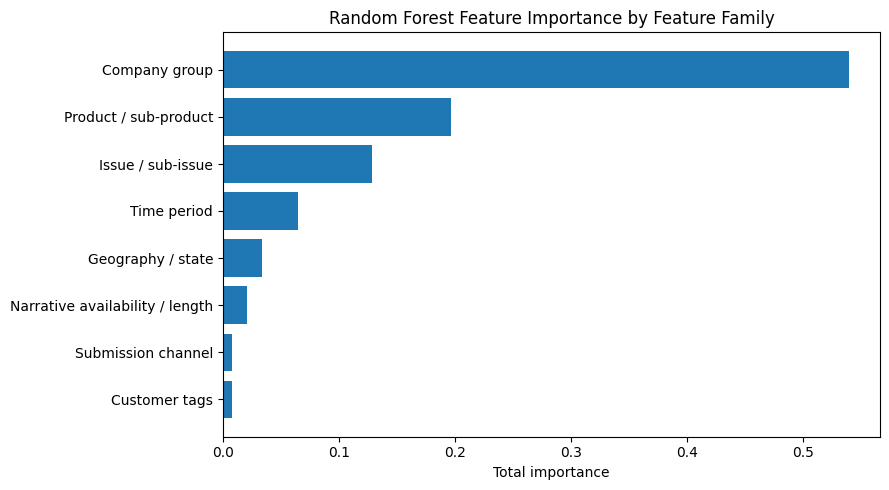

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/final_random_forest_feature_family_importance.png
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_interpreted_coefficients_structured_logistic_coefficients.csv

Interpreted coefficient table: Structured logistic coefficients


,feature_clean,feature_family,coefficient,direction
0,company grouped Other,Company group,-4.5911,Lower predicted probability of timely response...
1,"company grouped BANK OF AMERICA, NATIONAL ASSO...",Company group,-3.8684,Lower predicted probability of timely response...
2,sub issue You never received your bill or did ...,Issue / sub-issue,3.8595,Higher predicted probability of timely response
3,"company grouped Shellpoint Partners, LLC",Company group,-3.7240,Lower predicted probability of timely response...
4,company grouped Netspend Corporation,Company group,-3.6676,Lower predicted probability of timely response...
5,company grouped TRUIST FINANCIAL CORPORATION,Company group,-3.4148,Lower predicted probability of timely response...
6,"company grouped Block, Inc.",Company group,-3.3862,Lower predicted probability of timely response...
7,company grouped WELLS FARGO & COMPANY,Company group,-3.3708,Lower predicted probability of timely response...
8,"company grouped LoanCare, LLC",Company group,-3.3397,Lower predicted probability of timely response...
9,sub product Conventional adjustable mortgage (...,Product / sub-product,3.1231,Higher predicted probability of timely response


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_interpreted_coefficients_structured_plus_tf_idf_logistic_coefficients.csv

Interpreted coefficient table: Structured + TF-IDF logistic coefficients


,feature_clean,feature_family,coefficient,direction
0,text: codes,Narrative text term,-4.8324,Lower predicted probability of timely response...
1,text: better,Narrative text term,-4.7166,Lower predicted probability of timely response...
2,company grouped Other,Company group,-4.4945,Lower predicted probability of timely response...
3,text: years ago,Narrative text term,-4.4919,Lower predicted probability of timely response...
4,text: forged,Narrative text term,-4.3694,Lower predicted probability of timely response...
5,text: billing,Narrative text term,-4.3670,Lower predicted probability of timely response...
6,text: provide,Narrative text term,4.3509,Higher predicted probability of timely response
7,text: disbursement,Narrative text term,-4.3263,Lower predicted probability of timely response...
8,text: california,Narrative text term,-4.1091,Lower predicted probability of timely response...
9,text: coverage,Narrative text term,-4.0987,Lower predicted probability of timely response...


In [35]:
# -------------------------------------------------------------------
# Feature-family interpretation for random forest and coefficients
# -------------------------------------------------------------------
rf_table = feature_tables.get("Random forest feature importance", pd.DataFrame())

if not rf_table.empty and "importance" in rf_table.columns:
    rf_family = rf_table.copy()
    rf_family["feature_family"] = rf_family["feature"].apply(feature_family)
    rf_family_summary = (
        rf_family
        .groupby("feature_family", as_index=False)
        .agg(
            total_importance=("importance", "sum"),
            feature_count=("feature", "count"),
            top_feature=("feature", lambda x: clean_feature_name(x.iloc[0]))
        )
        .sort_values("total_importance", ascending=False)
    )
    rf_family_summary["importance_percent"] = (rf_family_summary["total_importance"] / rf_family_summary["total_importance"].sum() * 100).round(2)
    rf_family_summary = round_numeric_columns(rf_family_summary, 4)

    save_table(rf_family_summary, "final_random_forest_feature_family_importance.csv")
    display(rf_family_summary)

    plt.figure(figsize=(9, 5))
    plot_family = rf_family_summary.sort_values("total_importance", ascending=True)
    plt.barh(plot_family["feature_family"], plot_family["total_importance"])
    plt.title("Random Forest Feature Importance by Feature Family")
    plt.xlabel("Total importance")
    plt.tight_layout()

    feature_family_fig = OUTPUT_FIGURES / "final_random_forest_feature_family_importance.png"
    plt.savefig(feature_family_fig, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved figure:", feature_family_fig)
else:
    print("Random forest feature-importance table not available.")

# Create simplified interpretation tables for logistic coefficients.
for label, table in feature_tables.items():
    if "coefficient" in table.columns:
        coef_interpretation = table.copy()
        coef_interpretation["feature_clean"] = coef_interpretation["feature"].apply(clean_feature_name)
        coef_interpretation["feature_family"] = coef_interpretation["feature"].apply(feature_family)
        coef_interpretation["direction"] = np.where(
            coef_interpretation["coefficient"] > 0,
            "Higher predicted probability of timely response",
            "Lower predicted probability of timely response / higher non-timely risk"
        )
        coef_interpretation["absolute_coefficient"] = coef_interpretation["coefficient"].abs()
        coef_interpretation = coef_interpretation.sort_values("absolute_coefficient", ascending=False).head(40)
        coef_interpretation = round_numeric_columns(coef_interpretation, 4)

        safe_label = label.lower().replace(" ", "_").replace("+", "plus").replace("-", "_")
        save_table(coef_interpretation, f"final_interpreted_coefficients_{safe_label}.csv")
        print("\nInterpreted coefficient table:", label)
        display(coef_interpretation[["feature_clean", "feature_family", "coefficient", "direction"]].head(20))


## Main Analysis: Feature Family Importance and Interpreted Coefficients

The feature-family importance chart shows that the final random forest model relies most heavily on **company-level information**. Company group accounts for **53.94%** of total feature importance, which is much larger than any other feature family. This confirms that company-level patterns are the strongest operational signal in the final model.

The second most important feature family is **product/sub-product**, with **19.70%** of total importance. This supports the earlier finding that response-timeliness risk varies by product type. Product categories such as credit card, prepaid card, payday/personal loans, mortgage, money transfer, and checking accounts all contribute useful predictive information.

The third strongest feature family is **issue/sub-issue**, with **12.89%** of total importance. This means complaint type and complaint detail help the model understand operational complexity and routing patterns. For example, unknown sub-issues and transaction-related issues appear as important predictors.

Time period contributes **6.49%**, which suggests that complaint response patterns changed across years. This supports the need for periodic model retraining because operational conditions, reporting practices, company behavior, and complaint volumes may shift over time.

Geography/state contributes **3.34%**, which means state-level information adds some signal but is much weaker than company, product, and issue variables. It should be treated as a supporting context variable rather than a primary risk driver.

Narrative availability and narrative length contribute **2.05%**. This shows that even without full TF-IDF text, basic narrative-related information helps the model. Narrative length may reflect complaint complexity, customer effort, or the amount of detail provided.

Submission channel and customer tags have very small contributions, both below **1%**. This suggests that how the complaint was submitted and whether it had a customer tag were less important than company, product, issue, and time-based features.

## Feature-Family Ranking

| Feature family                  | Total importance | Main interpretation                                |
| ------------------------------- | ---------------: | -------------------------------------------------- |
| Company group                   |           53.94% | Strongest operational signal                       |
| Product / sub-product           |           19.70% | Important complaint-type risk signal               |
| Issue / sub-issue               |           12.89% | Captures complaint complexity and routing patterns |
| Time period                     |            6.49% | Shows performance patterns vary by year            |
| Geography / state               |            3.34% | Adds supporting regional context                   |
| Narrative availability / length |            2.05% | Captures basic narrative complexity                |
| Submission channel              |            0.80% | Minor contribution                                 |
| Customer tags                   |            0.79% | Minor contribution                                 |

## Interpretation of Structured Logistic Coefficients

The structured logistic regression coefficients provide directional insight. Since the target is **timely response**, positive coefficients indicate a higher predicted probability of timely response, while negative coefficients indicate a lower predicted probability of timely response.

The structured logistic model shows that several company-group features have strong negative coefficients. These include the broad **Other** group, Bank of America, Shellpoint Partners, Netspend, Truist, Block, Wells Fargo, and LoanCare. This supports the random forest finding that company-level variables are important, but these coefficients should not be read as direct performance rankings. They are relative to the model’s reference category and may reflect complaint mix, company grouping, product complexity, customer base, or case volume.

Some product and issue variables have positive coefficients, such as conventional adjustable mortgage, manufactured home loan, home equity loan or line of credit, and certain sub-issues related to billing or card use. These features are associated with higher predicted timely-response probability in the model.

The important point is that logistic regression adds interpretability. It helps explain whether a feature pushes the prediction toward timely or non-timely response, while random forest importance only shows how useful the feature is for prediction.

## Interpretation of Structured + TF-IDF Logistic Coefficients

The TF-IDF logistic model adds narrative text terms to the structured features. This table shows that text terms become highly influential once narrative data is included.

Several narrative terms have negative coefficients, including terms such as **codes**, **years ago**, **forged**, **billing**, **disbursement**, **coverage**, **calls**, **visa**, **dealer**, **debit cards**, and **robinhood**. These terms may reflect fraud concerns, billing disputes, card issues, loan or dealer-related complaints, repeated contact, or unresolved issues. These are likely signs of complaint complexity.

Some narrative terms have positive coefficients, such as **provide**, **principal**, and **person**, which are associated with higher predicted probability of timely response. These terms may appear in complaints with clearer documentation, more standard response handling, or specific resolution paths.

This supports RQ3 because the narrative text contains additional signals beyond structured complaint fields. However, the TF-IDF coefficients should be interpreted carefully. A word does not directly cause a delayed or timely response. It only indicates that the word was statistically useful in prediction within the model.

## Overall Interpretation

The model interpretation results show that response-timeliness prediction is mainly driven by **company group**, followed by **product/sub-product**, **issue/sub-issue**, and **time period**. Narrative-related features also add useful information, especially when full TF-IDF text is included, but they are not the dominant driver in the final random forest model.

The strongest business insight is that complaint response risk is not random. It is concentrated around operational patterns linked to company groups, product types, complaint issues, and time periods. This supports using the model as a **risk-based triage tool** that combines multiple signals rather than relying on one variable.

The main caution is that company-level importance is very high, especially for the broad **Other** company group. This suggests that the company grouping strategy should be reviewed. The “Other” group may be too broad and may combine companies with very different complaint-handling patterns. Refining this group could improve model stability and reduce false alerts.


## Company Response Outcome Interpretation

In addition to timely-response modeling, the project also examines company response outcomes such as **Closed with explanation** and **Relief provided**. This section summarizes response-outcome imbalance and, when available, model classification results for the grouped company-response target.


In [36]:
# -------------------------------------------------------------------
# Company response outcome interpretation
# -------------------------------------------------------------------
company_response_distribution = optional_tables.get("company_response_distribution", pd.DataFrame())
company_response_report = optional_tables.get("company_response_classification_report", pd.DataFrame())

# Try alternate common filenames if the preferred report name is not available.
if company_response_report.empty:
    alternate_report_files = [
        OUTPUT_TABLES / "model_company_response_group_classification_report.csv",
        OUTPUT_TABLES / "company_response_classification_report.csv",
        OUTPUT_TABLES / "model_training_company_response_classification_report.csv",
    ]
    for alt_path in alternate_report_files:
        if alt_path.exists():
            company_response_report = pd.read_csv(alt_path)
            print("Loaded alternate company response report:", alt_path)
            break

if not company_response_distribution.empty:
    company_response_distribution = round_numeric_columns(company_response_distribution, 4)
    save_table(company_response_distribution, "final_company_response_target_distribution.csv")
    display(company_response_distribution)
else:
    print("Company response target distribution was not found. It can be generated in Notebook 04.")

if not company_response_report.empty:
    company_response_report = round_numeric_columns(company_response_report, 4)
    save_table(company_response_report, "final_company_response_classification_report.csv")
    display(company_response_report)
else:
    print("Company response classification report was not found. It can be generated in Notebook 04.")

company_response_notes = pd.DataFrame([
    {
        "finding_area": "Target imbalance",
        "interpretation": "Most records are closed with explanation, while relief and other response categories are smaller.",
        "business_meaning": "Accuracy alone may overstate model quality for company-response modeling."
    },
    {
        "finding_area": "Rare categories",
        "interpretation": "In-progress and other-response categories may have too few records for stable prediction.",
        "business_meaning": "Consider merging rare categories or using a simpler relief-versus-no-relief target."
    },
    {
        "finding_area": "Relief prediction",
        "interpretation": "Relief-provided predictions are useful for triage when recall is acceptable, but low precision may create false alerts.",
        "business_meaning": "Use for prioritization and analyst review, not automated outcome determination."
    }
])

save_table(company_response_notes, "final_company_response_modeling_notes.csv")
display(company_response_notes)


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_company_response_target_distribution.csv


,company_response_group,count,percent
0,Closed with explanation,1038396,80.56
1,Relief provided,247704,19.22
2,Other response,2844,0.22
3,In progress,22,0.00


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_company_response_classification_report.csv


,class,precision,recall,f1-score,support
0,Closed with explanation,0.9194,0.5515,0.6895,36252.0000
1,In progress,0.0000,0.0000,0.0000,1.0000
2,Other response,0.0151,0.7778,0.0296,99.0000
3,Relief provided,0.3628,0.7606,0.4913,8648.0000
4,accuracy,0.5922,0.5922,0.5922,0.5922
5,macro avg,0.3243,0.5225,0.3026,45000.0000
6,weighted avg,0.8104,0.5922,0.6499,45000.0000


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_company_response_modeling_notes.csv


,finding_area,interpretation,business_meaning
0,Target imbalance,"Most records are closed with explanation, whil...",Accuracy alone may overstate model quality for...
1,Rare categories,In-progress and other-response categories may ...,Consider merging rare categories or using a si...
2,Relief prediction,Relief-provided predictions are useful for tri...,"Use for prioritization and analyst review, not..."


### Company Response Outcome Modeling

This section evaluates the model built to predict **company response outcomes**, not just whether a complaint response was timely. The target variable has four grouped outcomes:

| Company response group  |     Count | Percent |
| ----------------------- | --------: | ------: |
| Closed with explanation | 1,038,396 |  80.56% |
| Relief provided         |   247,704 |  19.22% |
| Other response          |     2,844 |   0.22% |
| In progress             |        22 |   0.00% |

The distribution shows a strong class imbalance. Most complaints are closed with explanation, while about one-fifth result in some form of relief. The remaining categories are extremely small. This imbalance makes the company-response prediction problem harder than the timely-response model because the model must distinguish between several uneven outcome classes.

## 1. Target Distribution Interpretation

The dominant outcome is **Closed with explanation**, representing **80.56%** of records. This means most retail banking complaints end with the company explaining its position rather than providing relief.

The second major outcome is **Relief provided**, representing **19.22%** of records. This is an important business category because it may indicate complaints where the company provided monetary or non-monetary resolution. From an operational perspective, this group is useful for identifying complaint types that may create higher remediation, service recovery, or customer-impact risk.

The **Other response** and **In progress** categories are too small to model reliably as separate classes. “Other response” represents only **0.22%**, while “In progress” has only **22 records** in the full dataset. Because these categories are rare, the model has very limited examples to learn from.

## 2. Overall Model Performance

The classification report shows:

| Metric            |  Value |
| ----------------- | -----: |
| Accuracy          | 0.5922 |
| Macro F1-score    | 0.3026 |
| Weighted F1-score | 0.6499 |

The model achieved **59.22% accuracy**, which is moderate. However, accuracy alone is not enough because the target is imbalanced. The **weighted F1-score of 0.6499** looks better because it gives more weight to the larger classes, especially “Closed with explanation.”

The more important warning sign is the **macro F1-score of 0.3026**. Macro F1 treats all classes equally, so the low value shows that the model performs unevenly across response categories. It performs better on common outcomes and struggles with rare outcomes.

## 3. Closed With Explanation

For **Closed with explanation**, the model achieved:

| Metric    |  Value |
| --------- | -----: |
| Precision | 0.9194 |
| Recall    | 0.5515 |
| F1-score  | 0.6895 |
| Support   | 36,252 |

This class has high precision but moderate recall. When the model predicts “Closed with explanation,” it is usually correct. However, it only identifies about **55.15%** of the actual closed-with-explanation cases.

This means the model is cautious when assigning complaints to the majority class. It avoids over-predicting explanation outcomes, but as a result it misses many actual explanation cases.

## 4. Relief Provided

For **Relief provided**, the model achieved:

| Metric    |  Value |
| --------- | -----: |
| Precision | 0.3628 |
| Recall    | 0.7606 |
| F1-score  | 0.4913 |
| Support   |  8,648 |

This is one of the most useful findings. The model captures about **76.06%** of actual relief-provided cases. That is valuable because relief cases are operationally important. They may indicate complaints where financial correction, service recovery, or customer remediation is more likely.

However, the precision is only **36.28%**. This means many complaints predicted as “Relief provided” actually fall into other response categories. So the model should not be used to automatically decide whether relief will be provided. Instead, it can be used to create a **review queue** for complaints more likely to involve relief.

From a business view, this is still useful. It is better to flag possible relief cases for analyst review than to miss them completely, especially if the purpose is early triage.

## 5. Other Response

For **Other response**, the model achieved:

| Metric    |  Value |
| --------- | -----: |
| Precision | 0.0151 |
| Recall    | 0.7778 |
| F1-score  | 0.0296 |
| Support   |     99 |

The recall is high, but the precision is extremely low. This means the model captures many of the few actual “Other response” cases, but it also predicts this category far too often.

This is a typical rare-class problem. Because the class has only **99 test records**, small prediction changes can create unstable results. The model is trying to detect the rare class, but the predictions are not reliable enough for business use.

The “Other response” category should likely be merged with another category or handled as an exception group rather than treated as a separate modeling class.

## 6. In Progress

For **In progress**, the model achieved zero precision, recall, and F1-score. This is expected because there was only **1 test record** and only **22 records** in the full dataset.

This category is too small for supervised machine learning. The model cannot learn a stable pattern from such a small number of examples.

For the final study, “In progress” should not be treated as an independent predictive class. It should either be merged into “Other response” or excluded from company-response modeling.

## 7. Business Meaning

The company-response model is useful for **directional triage**, especially for identifying complaints that may result in relief. The relief class has strong recall, which means the model can help surface many potentially important cases for review.

However, the model is not strong enough for automatic outcome prediction. The low precision for relief and rare classes means that many flagged cases will require human validation.

The practical use case is:

```text
Use the model to prioritize complaints for analyst review,
not to automatically determine the final company response outcome.
```

## 8. Modeling Recommendation

The current four-class target is useful for exploration, but it may be too imbalanced for stable operational modeling. A simpler target would likely perform better and be easier to explain.

The strongest option is:

```text
Relief provided vs. No relief provided
```

This would turn the problem into a binary classification task. It would directly answer a practical business question: which complaints are more likely to result in customer relief?

Another option is:

```text
Closed with explanation
Relief provided
Other / In progress
```

This keeps three categories but avoids treating “In progress” as a standalone class.

For the capstone, the binary relief model may be the most business-friendly because it connects directly to complaint remediation, customer impact, and operational prioritization.

## 9. Overall Interpretation

The company-response outcome model shows that response outcome prediction is possible but challenging due to strong class imbalance. The model performs reasonably for the two major classes, especially by identifying many **Relief provided** cases. However, it struggles with rare categories such as **Other response** and **In progress**.

The key business value is not perfect prediction. The value is early identification of complaints that may require closer review because they are more likely to involve relief. This supports complaint triage, root-cause analysis, and prioritization of high-impact cases.

The final conclusion is that company-response modeling should be treated as a **decision-support tool**, not an automated response-decision system. For stronger future modeling, rare categories should be merged, and a simplified **relief vs. no-relief** target should be considered.


## Step 12: Business Interpretation Tables

This section converts the technical results into business-friendly findings and recommendations.

In [37]:
# -------------------------------------------------------------------
# Create final business findings and recommendations table
# -------------------------------------------------------------------

business_findings = []

# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

def fmt_num(value, decimals=4):
    """Safely format numeric values for business text."""
    try:
        return f"{float(value):.{decimals}f}"
    except Exception:
        return "N/A"


def fmt_pct(value, decimals=2):
    """Safely format percentage values for business text."""
    try:
        return f"{float(value):.{decimals}f}%"
    except Exception:
        return "N/A"


def add_business_finding(
    related_rq,
    finding_area,
    technical_finding,
    business_meaning,
    recommended_action,
    governance_note,
    priority="Medium"
):
    """Append one standardized business finding row."""
    business_findings.append({
        "related_rq": related_rq,
        "finding_area": finding_area,
        "technical_finding": technical_finding,
        "business_meaning": business_meaning,
        "recommended_action": recommended_action,
        "governance_note": governance_note,
        "priority": priority
    })


# -------------------------------------------------------------------
# 1. Best predictive model
# -------------------------------------------------------------------

if "model_performance" in globals() and not model_performance.empty:
    best_row = model_performance.sort_values("roc_auc", ascending=False).iloc[0]

    add_business_finding(
        related_rq="RQ3 / RQ4",
        finding_area="Best predictive model",
        technical_finding=(
            f"The best model by ROC-AUC was {best_row['model']} "
            f"with ROC-AUC of {fmt_num(best_row['roc_auc'])}, "
            f"balanced accuracy of {fmt_num(best_row['balanced_accuracy'])}, "
            f"and F1-score of {fmt_num(best_row['f1'])}."
        ),
        business_meaning=(
            "Complaint metadata can be used to rank complaints by response-timeliness risk. "
            "The structured random forest provides the strongest balanced risk-detection performance "
            "among the tested models."
        ),
        recommended_action=(
            "Use the structured random forest as the preferred model for response-timeliness "
            "risk triage and monitoring."
        ),
        governance_note=(
            "Use the model as a decision-support tool, not as an automated decision-maker. "
            "Monitor drift, subgroup performance, false alerts, and missed-risk cases."
        ),
        priority="High"
    )


# -------------------------------------------------------------------
# 2. Accuracy limitation and class imbalance
# -------------------------------------------------------------------

add_business_finding(
    related_rq="Model Evaluation",
    finding_area="Accuracy limitation",
    technical_finding=(
        "The dummy baseline achieved high accuracy because timely responses dominate the dataset, "
        "but its balanced accuracy and ROC-AUC were both 0.5000."
    ),
    business_meaning=(
        "Accuracy alone is misleading in this imbalanced classification problem. "
        "A model can look accurate while failing to detect rare non-timely complaints."
    ),
    recommended_action=(
        "Use ROC-AUC, balanced accuracy, classwise precision, classwise recall, F1-score, "
        "average precision, confusion matrices, and threshold analysis."
    ),
    governance_note=(
        "Clearly disclose target imbalance in the final paper and avoid selecting models "
        "based on accuracy alone."
    ),
    priority="High"
)


# -------------------------------------------------------------------
# 3. Final non-timely risk performance
# -------------------------------------------------------------------

if "best_model_risk_metrics" in globals() and not best_model_risk_metrics.empty:
    risk_row = best_model_risk_metrics.iloc[0]

    add_business_finding(
        related_rq="Model Evaluation",
        finding_area="Non-timely risk detection",
        technical_finding=(
            f"The final model captured non-timely complaints with recall of "
            f"{fmt_num(risk_row['recall_non_timely'])}, precision of "
            f"{fmt_num(risk_row['precision_non_timely'])}, and non-timely F1-score of "
            f"{fmt_num(risk_row['f1_non_timely'])}."
        ),
        business_meaning=(
            "The model is strong at catching many delayed-response risk cases, but the low "
            "precision means many flagged complaints will still be timely."
        ),
        recommended_action=(
            "Use the model to create an early-warning review queue for complaint teams, "
            "with human review before escalation."
        ),
        governance_note=(
            "Track both missed non-timely complaints and false-alert workload. "
            "Do not automate customer-impacting decisions from this model alone."
        ),
        priority="High"
    )


# -------------------------------------------------------------------
# 4. Non-timely risk threshold
# -------------------------------------------------------------------

if "best_risk_threshold" in globals() and not best_risk_threshold.empty:
    threshold_row = best_risk_threshold.iloc[0]

    add_business_finding(
        related_rq="Model Evaluation",
        finding_area="Non-timely risk threshold",
        technical_finding=(
            f"The selected tested non-timely risk threshold was "
            f"{fmt_num(threshold_row['risk_threshold'], 2)}. "
            f"It flagged {int(threshold_row['flagged_records'])} records "
            f"({fmt_pct(threshold_row['flagged_percent'])}), with non-timely precision of "
            f"{fmt_num(threshold_row['precision_non_timely'])}, recall of "
            f"{fmt_num(threshold_row['recall_non_timely'])}, and F1-score of "
            f"{fmt_num(threshold_row['f1_non_timely'])}."
        ),
        business_meaning=(
            "The selected threshold creates a smaller, higher-confidence risk queue. "
            "It improves alert quality, but it will miss many actual non-timely complaints."
        ),
        recommended_action=(
            "Select the final operating threshold based on complaint-team review capacity. "
            "Use a lower threshold when the priority is to catch more delayed-risk cases, "
            "and a higher threshold when the priority is a smaller high-confidence queue."
        ),
        governance_note=(
            "Document the threshold rationale and review it periodically using recent complaints, "
            "false-alert rates, and missed-risk rates."
        ),
        priority="High"
    )


# -------------------------------------------------------------------
# 5. RQ3 narrative value
# -------------------------------------------------------------------

if "rq3_interpretation" in globals() and not rq3_interpretation.empty:
    add_business_finding(
        related_rq="RQ3",
        finding_area="Narrative value",
        technical_finding=(
            "Adding TF-IDF narrative features improved accuracy, timely recall, and timely F1-score. "
            "However, it reduced balanced accuracy, non-timely recall, ROC-AUC for non-timely risk, "
            "and average precision for non-timely risk."
        ),
        business_meaning=(
            "Customer-written narratives provide useful context and improve overall prediction, "
            "but they do not automatically improve rare non-timely risk detection."
        ),
        recommended_action=(
            "Use narrative analytics as a supporting triage signal together with structured features. "
            "For operational use, combine text features with threshold tuning and human review."
        ),
        governance_note=(
            "Narratives are available only for part of the dataset and may contain sensitive customer details. "
            "Text features should be handled with privacy, fairness, and explainability controls."
        ),
        priority="Medium"
    )


# -------------------------------------------------------------------
# 6. RQ4 company and geography incremental value
# -------------------------------------------------------------------

rq4_table = pd.DataFrame()

if "optional_tables" in globals():
    rq4_table = optional_tables.get(
        "rq4_base_vs_company_state",
        optional_tables.get("final_rq4_company_state_incremental_value", pd.DataFrame())
    )

if rq4_table.empty and "rq4_base_vs_company_state" in globals():
    rq4_table = rq4_base_vs_company_state

if not rq4_table.empty:
    diff_rows = rq4_table[rq4_table["model"].astype(str).str.contains("Difference", case=False, na=False)]

    if not diff_rows.empty:
        rq4_diff = diff_rows.iloc[0]

        add_business_finding(
            related_rq="RQ4",
            finding_area="Company and geography signals",
            technical_finding=(
                "Adding company and state features improved model performance beyond complaint "
                f"characteristics alone. Balanced accuracy improved by "
                f"{fmt_num(rq4_diff['balanced_accuracy'])}, and ROC-AUC improved by "
                f"{fmt_num(rq4_diff['roc_auc'])}."
            ),
            business_meaning=(
                "Company and geography provide additional operational risk signals. "
                "Company-level signals appear especially important for predicting response timeliness."
            ),
            recommended_action=(
                "Use company and state features for internal monitoring, governance review, "
                "risk-based triage, and operational benchmarking."
            ),
            governance_note=(
                "Do not treat company or state features as direct public performance rankings. "
                "The model does not fully control for market share, customer base, complaint volume, "
                "product mix, or case complexity."
            ),
            priority="High"
        )


# -------------------------------------------------------------------
# 7. Feature-family importance
# -------------------------------------------------------------------

feature_family_table = pd.DataFrame()

if "feature_family_importance" in globals() and not feature_family_importance.empty:
    feature_family_table = feature_family_importance
elif "feature_family_importance_df" in globals() and not feature_family_importance_df.empty:
    feature_family_table = feature_family_importance_df

if not feature_family_table.empty:
    top_family = feature_family_table.sort_values("total_importance", ascending=False).iloc[0]

    add_business_finding(
        related_rq="RQ1 / RQ2 / RQ4",
        finding_area="Feature-family importance",
        technical_finding=(
            f"The most important feature family was {top_family['feature_family']}, "
            f"accounting for {fmt_pct(top_family['importance_percent'])} of total model importance."
        ),
        business_meaning=(
            "Response-timeliness risk is mainly driven by operational signals, especially company group, "
            "followed by product/sub-product, issue/sub-issue, and time period."
        ),
        recommended_action=(
            "Use feature-family importance to guide monitoring dashboards and business review priorities."
        ),
        governance_note=(
            "Random forest importance shows predictive usefulness, not causation. "
            "High-cardinality fields such as company group may receive higher importance and should be reviewed carefully."
        ),
        priority="Medium"
    )


# -------------------------------------------------------------------
# 8. Product-level error concentration
# -------------------------------------------------------------------

if "error_tables" in globals() and "product" in error_tables and len(error_tables["product"]) > 0:
    top_error_product_row = error_tables["product"].iloc[0]
    top_error_product = top_error_product_row["product"]

    add_business_finding(
        related_rq="RQ1",
        finding_area="Product-level error concentration",
        technical_finding=(
            f"The highest model error rate among product groups appears in: {top_error_product}, "
            f"with an error rate of {fmt_pct(top_error_product_row['error_rate_percent'])}."
        ),
        business_meaning=(
            "Some product groups have more complex or less stable complaint patterns. "
            "The model may over-flag these products as delayed-response risks."
        ),
        recommended_action=(
            "Review product-level complaint workflows, escalation rules, and model calibration for high-error products."
        ),
        governance_note=(
            "Do not infer causality from error concentration. Use product-level results as prompts for business review."
        ),
        priority="Medium"
    )


# -------------------------------------------------------------------
# 9. Issue-level error concentration
# -------------------------------------------------------------------

if "error_tables" in globals() and "issue" in error_tables and len(error_tables["issue"]) > 0:
    top_error_issue_row = error_tables["issue"].iloc[0]
    top_error_issue = top_error_issue_row["issue"]

    add_business_finding(
        related_rq="RQ2",
        finding_area="Issue-level error concentration",
        technical_finding=(
            f"The highest model error rate among issue groups appears in: {top_error_issue}, "
            f"with an error rate of {fmt_pct(top_error_issue_row['error_rate_percent'])}."
        ),
        business_meaning=(
            "Certain complaint issues may involve greater operational complexity, unclear routing, "
            "or more variable response patterns."
        ),
        recommended_action=(
            "Use issue-level monitoring to improve routing, triage, escalation, and response playbooks."
        ),
        governance_note=(
            "Pair model results with complaint operations and subject-matter expert review."
        ),
        priority="Medium"
    )


# -------------------------------------------------------------------
# 10. Company-group error concentration
# -------------------------------------------------------------------

if "error_tables" in globals() and "company_grouped" in error_tables and len(error_tables["company_grouped"]) > 0:
    top_error_company_row = error_tables["company_grouped"].iloc[0]
    top_error_company = top_error_company_row["company_grouped"]

    add_business_finding(
        related_rq="RQ4",
        finding_area="Company-group error concentration",
        technical_finding=(
            f"The highest company-group error rate appears in: {top_error_company}, "
            f"with an error rate of {fmt_pct(top_error_company_row['error_rate_percent'])}."
        ),
        business_meaning=(
            "The broad company grouping may combine organizations with very different complaint patterns, "
            "making predictions less stable."
        ),
        recommended_action=(
            "Refine the broad company grouping by separating smaller banks, fintech/payment firms, "
            "mortgage servicers, credit unions, and other low-volume institutions where possible."
        ),
        governance_note=(
            "Avoid using company-level model outputs as direct rankings. Review grouping logic and subgroup fairness."
        ),
        priority="High"
    )


# -------------------------------------------------------------------
# 11. Subgroup performance monitoring
# -------------------------------------------------------------------

subgroup_tables_available = (
    "subgroup_tables" in globals()
    and isinstance(subgroup_tables, dict)
    and len(subgroup_tables) > 0
)

if subgroup_tables_available:
    add_business_finding(
        related_rq="Model Governance",
        finding_area="Subgroup performance",
        technical_finding=(
            "Subgroup results show that model performance varies across product, company, state, "
            "submission channel, and year groups."
        ),
        business_meaning=(
            "The model is not equally stable across all segments. Some groups may receive more false alerts "
            "or weaker risk detection than others."
        ),
        recommended_action=(
            "Monitor subgroup accuracy, balanced accuracy, precision, recall, and false-alert rates before deployment."
        ),
        governance_note=(
            "Use subgroup monitoring to support fairness, transparency, and responsible AI governance."
        ),
        priority="High"
    )


# -------------------------------------------------------------------
# 12. Company response outcome modeling
# -------------------------------------------------------------------

if "company_response_distribution" in globals() and not company_response_distribution.empty:
    dominant_response = company_response_distribution.sort_values("count", ascending=False).iloc[0]

    add_business_finding(
        related_rq="RQ2",
        finding_area="Company response outcome modeling",
        technical_finding=(
            f"The dominant company response outcome was {dominant_response['company_response_group']}, "
            f"representing {fmt_pct(dominant_response['percent'])} of records."
        ),
        business_meaning=(
            "Company response prediction is affected by strong class imbalance. "
            "Rare response categories are difficult to model reliably."
        ),
        recommended_action=(
            "Consider simplifying the target to relief provided versus no relief provided, "
            "or merge rare categories such as Other response and In progress."
        ),
        governance_note=(
            "Use response outcome predictions for triage and analyst review, not automated response decisions."
        ),
        priority="Medium"
    )


# -------------------------------------------------------------------
# 13. Overall model governance
# -------------------------------------------------------------------

add_business_finding(
    related_rq="Model Governance",
    finding_area="Model governance",
    technical_finding=(
        "The model is trained on observational public complaint data and reflects historical patterns "
        "in complaint submission, company response, product mix, and reporting practices."
    ),
    business_meaning=(
        "The model can support complaint triage, monitoring, and governance review, but it cannot prove causality."
    ),
    recommended_action=(
        "Use human review, model documentation, subgroup monitoring, threshold governance, and periodic retraining "
        "before any operational deployment."
    ),
    governance_note=(
        "Maintain model documentation, approval controls, audit evidence, privacy safeguards, "
        "and clear limitations in all reporting."
    ),
    priority="High"
)


# -------------------------------------------------------------------
# Final table
# -------------------------------------------------------------------

business_findings_df = pd.DataFrame(business_findings)

business_findings_path = save_table(
    business_findings_df,
    "final_business_findings_and_recommendations.csv"
)

display(business_findings_df)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_business_findings_and_recommendations.csv


,related_rq,finding_area,technical_finding,business_meaning,recommended_action,governance_note,priority
0,RQ3 / RQ4,Best predictive model,The best model by ROC-AUC was Structured rando...,Complaint metadata can be used to rank complai...,Use the structured random forest as the prefer...,"Use the model as a decision-support tool, not ...",High
1,Model Evaluation,Accuracy limitation,The dummy baseline achieved high accuracy beca...,Accuracy alone is misleading in this imbalance...,"Use ROC-AUC, balanced accuracy, classwise prec...",Clearly disclose target imbalance in the final...,High
2,Model Evaluation,Non-timely risk threshold,The selected tested non-timely risk threshold ...,"The selected threshold creates a smaller, high...",Select the final operating threshold based on ...,Document the threshold rationale and review it...,High
3,RQ3,Narrative value,Adding TF-IDF narrative features improved accu...,Customer-written narratives provide useful con...,Use narrative analytics as a supporting triage...,Narratives are available only for part of the ...,Medium
4,RQ4,Company and geography signals,Adding company and state features improved mod...,Company and geography provide additional opera...,Use company and state features for internal mo...,Do not treat company or state features as dire...,High
5,RQ1,Product-level error concentration,The highest model error rate among product gro...,Some product groups have more complex or less ...,"Review product-level complaint workflows, esca...",Do not infer causality from error concentratio...,Medium
6,RQ2,Issue-level error concentration,The highest model error rate among issue group...,Certain complaint issues may involve greater o...,"Use issue-level monitoring to improve routing,...",Pair model results with complaint operations a...,Medium
7,RQ4,Company-group error concentration,The highest company-group error rate appears i...,The broad company grouping may combine organiz...,Refine the broad company grouping by separatin...,Avoid using company-level model outputs as dir...,High
8,Model Governance,Subgroup performance,Subgroup results show that model performance v...,The model is not equally stable across all seg...,"Monitor subgroup accuracy, balanced accuracy, ...","Use subgroup monitoring to support fairness, t...",High
9,RQ2,Company response outcome modeling,The dominant company response outcome was Clos...,Company response prediction is affected by str...,Consider simplifying the target to relief prov...,Use response outcome predictions for triage an...,Medium


## Executive-Ready Business Observations

This section creates a concise table that can be copied into the final report or presentation. It aligns each research question with the business interpretation and the practical use of the findings.


In [38]:
# -------------------------------------------------------------------
# Executive-ready business observations
# -------------------------------------------------------------------

executive_observations = pd.DataFrame([
    {
        "research_question": "RQ1",
        "finding_area": "Product-level response risk",
        "business_observation": (
            "Response-timeliness risk is not evenly distributed across retail banking products. "
            "Product and sub-product variables were important predictors in the final model, "
            "with product/sub-product features contributing 19.70% of total random forest feature importance."
        ),
        "business_use": (
            "Use product-level monitoring to identify complaint areas that may need staffing review, "
            "faster escalation, workflow redesign, or more specialized handling."
        ),
        "caution": (
            "Product type should be treated as one operational risk signal, not as a complete explanation "
            "of delayed response. Some product groups also showed higher false-alert rates, so product-level "
            "model outputs should be reviewed with operational context."
        )
    },
    {
        "research_question": "RQ2",
        "finding_area": "Issue-level response patterns",
        "business_observation": (
            "Complaint issue and sub-issue categories are linked to different response outcomes and model behavior. "
            "Issue/sub-issue features contributed 12.89% of total random forest feature importance, showing that "
            "complaint type helps explain response-timeliness patterns and likely resolution paths."
        ),
        "business_use": (
            "Use issue-level insights to improve complaint routing, specialist assignment, escalation rules, "
            "response playbooks, and root-cause analysis."
        ),
        "caution": (
            "Issue category should be interpreted together with product, company group, submission channel, "
            "geography, year, and complaint complexity. Rare or unclear issue groups may require manual review."
        )
    },
    {
        "research_question": "RQ3",
        "finding_area": "Value of customer narratives",
        "business_observation": (
            "Customer-written narratives add useful predictive context. The structured + TF-IDF model improved "
            "overall accuracy, timely recall, and timely F1-score compared with structured logistic regression. "
            "However, it did not improve every imbalance-sensitive metric, and non-timely recall declined."
        ),
        "business_use": (
            "Use NLP and text analytics as supporting triage signals to identify complaint complexity, customer effort, "
            "fraud concerns, billing problems, repeated follow-ups, and other narrative-based risk indicators."
        ),
        "caution": (
            "Narratives are available only for part of the dataset and may contain sensitive customer details. "
            "Narrative features should not be used alone; they should be combined with structured variables, "
            "threshold tuning, privacy controls, and human review."
        )
    },
    {
        "research_question": "RQ4",
        "finding_area": "Company and geography signals",
        "business_observation": (
            "Company and state variables add predictive value beyond complaint characteristics. Adding company and "
            "state features improved balanced accuracy by 0.1418 and ROC-AUC by 0.1479. Company group was the "
            "dominant feature family, contributing 53.94% of total random forest feature importance."
        ),
        "business_use": (
            "Use company and geography signals for internal monitoring, governance review, regional analysis, "
            "risk-based triage, and careful operational benchmarking."
        ),
        "caution": (
            "Company and state variables should not be interpreted as direct performance rankings. The data does not "
            "fully control for market share, customer base, complaint volume, product mix, servicing model, or case complexity. "
            "The broad 'Other' company group should be reviewed because it showed high importance and high error concentration."
        )
    },
    {
        "research_question": "Model Evaluation",
        "finding_area": "Best model and class imbalance",
        "business_observation": (
            "The structured random forest was the best model by ROC-AUC, achieving ROC-AUC of 0.8748 and balanced "
            "accuracy of 0.8000. The dummy baseline had high accuracy, but its balanced accuracy and ROC-AUC were only 0.5000, "
            "confirming that accuracy alone is misleading in this imbalanced dataset."
        ),
        "business_use": (
            "Use ROC-AUC, balanced accuracy, classwise recall, classwise precision, F1-score, average precision, "
            "confusion matrices, and threshold analysis when evaluating complaint-risk models."
        ),
        "caution": (
            "The model should be selected for risk-detection value, not simple accuracy. Non-timely complaints are rare, "
            "so minority-class performance must be monitored separately."
        )
    },
    {
        "research_question": "Model Evaluation",
        "finding_area": "Non-timely risk detection",
        "business_observation": (
            "The final structured random forest captured 81.20% of actual non-timely complaints at the default threshold, "
            "showing strong recall for the rare risk class. However, non-timely precision was low, meaning many flagged "
            "complaints were false alerts."
        ),
        "business_use": (
            "Use the model as an early-warning triage tool to create a risk-review queue for complaint teams. "
            "Thresholds can be adjusted depending on whether the business prefers broader risk coverage or a smaller, "
            "higher-confidence alert list."
        ),
        "caution": (
            "The model should not trigger automatic complaint decisions. Human review is required, especially for high-risk, "
            "sensitive, or complex complaints."
        )
    },
    {
        "research_question": "Company Response Modeling",
        "finding_area": "Response outcome prediction",
        "business_observation": (
            "Company response outcomes are highly imbalanced. Most complaints were closed with explanation, while relief-provided "
            "cases represented a smaller but operationally important group. The model showed useful recall for relief-provided cases, "
            "but rare categories such as Other response and In progress were not stable enough for reliable standalone prediction."
        ),
        "business_use": (
            "Use response outcome modeling for triage, analyst review, and identifying complaints more likely to involve relief, "
            "remediation, or customer-impact review."
        ),
        "caution": (
            "Consider simplifying the response target to relief provided versus no relief provided, or merge rare categories. "
            "Do not use the model to automatically determine final company response outcomes."
        )
    },
    {
        "research_question": "Overall",
        "finding_area": "Integrated risk-based triage",
        "business_observation": (
            "Complaint outcomes are shaped by multiple interacting signals: product, sub-product, issue, sub-issue, company group, "
            "geography, narrative content, channel, customer tags, and time period. No single variable fully explains response risk."
        ),
        "business_use": (
            "Combine these signals into a risk-based complaint triage and monitoring framework that supports early-warning review, "
            "capacity planning, escalation prioritization, and governance reporting."
        ),
        "caution": (
            "Model output should be used as decision support with human oversight. The model is based on observational public complaint data, "
            "so results should be interpreted as predictive associations, not causal proof."
        )
    }
])

save_table(
    executive_observations,
    "final_executive_ready_business_observations.csv"
)

display(executive_observations)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_executive_ready_business_observations.csv


,research_question,finding_area,business_observation,business_use,caution
0,RQ1,Product-level response risk,Response-timeliness risk is not evenly distrib...,"Product-level monitoring, staffing review, esc...","Product type is one risk signal, not a complet..."
1,RQ2,Issue-level response patterns,Complaint issue category is linked to differen...,"Complaint routing, specialist assignment, issu...",Issue category should be interpreted with prod...
2,RQ3,Value of customer narratives,Customer-written narratives add useful context...,"NLP-based triage, risk detection, and prioriti...",Narrative features did not improve every imbal...
3,RQ4,Company and geography signals,Company and state variables add predictive val...,"Governance review, operational monitoring, reg...",Do not treat company or state variables as dir...
4,Overall,Integrated risk-based triage,Complaint outcomes are shaped by multiple inte...,Combine signals into a risk-based complaint tr...,Use model output as decision support with huma...


In [39]:
# -------------------------------------------------------------------
# Create implementation roadmap
# -------------------------------------------------------------------

implementation_roadmap = pd.DataFrame([
    {
        "phase": "Phase 1",
        "focus": "Analytical validation and model readiness",
        "activities": (
            "Validate final model results, confirm the structured random forest as the preferred model, "
            "review ROC-AUC, balanced accuracy, classwise precision and recall, confusion matrix results, "
            "feature-family importance, subgroup performance, and error concentration."
        ),
        "owner": "Analytics team with complaint operations",
        "expected_output": (
            "Validated model interpretation pack, including model performance, threshold trade-off, "
            "feature importance, subgroup analysis, and error analysis."
        ),
        "risk_control": (
            "Document class imbalance, target definition, feature exclusions, leakage controls, "
            "model assumptions, limitations, and why accuracy alone was not used for selection."
        )
    },
    {
        "phase": "Phase 2",
        "focus": "Business validation and operational review",
        "activities": (
            "Review high-risk product groups, issue groups, company groups, state patterns, and year-level trends "
            "with complaint operations and subject-matter experts. Pay special attention to high-error areas such as "
            "payday/personal loan products, mortgage-related complaints, fee-related issues, and the broad Other company group."
        ),
        "owner": "Complaint operations, analytics, risk, and business product owners",
        "expected_output": (
            "Business-validated list of priority risk segments and model interpretation notes."
        ),
        "risk_control": (
            "Do not treat model outputs as causal findings or direct company rankings. Validate findings against "
            "business context, complaint volume, product mix, case complexity, and operating model differences."
        )
    },
    {
        "phase": "Phase 3",
        "focus": "Threshold calibration",
        "activities": (
            "Select the non-timely risk threshold based on complaint-team review capacity, false-alert tolerance, "
            "missed-risk tolerance, and escalation policy. Compare lower thresholds for broad risk capture against "
            "higher thresholds for smaller, higher-confidence review queues."
        ),
        "owner": "Complaint operations, analytics, risk, and compliance",
        "expected_output": (
            "Approved operating threshold with documented precision, recall, F1-score, flagged volume, "
            "and expected review workload."
        ),
        "risk_control": (
            "Document threshold rationale. Review threshold performance periodically using recent complaints, "
            "false-alert rates, missed non-timely cases, and operational capacity."
        )
    },
    {
        "phase": "Phase 4",
        "focus": "Pilot dashboard and monitoring view",
        "activities": (
            "Create a complaint-risk dashboard showing predicted non-timely risk, risk threshold, product, issue, "
            "company group, state, submission channel, narrative availability, narrative length, year, and top risk segments. "
            "Include separate views for flagged complaints, high-error segments, subgroup performance, and trend monitoring."
        ),
        "owner": "Operations analytics, complaint management, and technology",
        "expected_output": (
            "Pilot dashboard for complaint triage, monitoring, and management review."
        ),
        "risk_control": (
            "Show model scores as decision-support indicators only. Clearly label predictions, confidence limits, "
            "threshold logic, and human-review requirements."
        )
    },
    {
        "phase": "Phase 5",
        "focus": "Workflow integration and human review",
        "activities": (
            "Integrate the model into complaint-review workflow as a triage signal. Route selected high-risk complaints "
            "for earlier review, supervisor monitoring, specialist handling, or escalation based on approved business rules."
        ),
        "owner": "Complaint operations, technology, risk, and compliance",
        "expected_output": (
            "Controlled pilot workflow for risk-based complaint review and escalation."
        ),
        "risk_control": (
            "Keep human-in-the-loop controls. Prohibit automated adverse treatment or final complaint decisions based only "
            "on model output. Maintain clear ownership for reviewing and acting on alerts."
        )
    },
    {
        "phase": "Phase 6",
        "focus": "Model governance and responsible AI controls",
        "activities": (
            "Establish ongoing monitoring for model drift, subgroup performance, product-level errors, issue-level errors, "
            "company-group stability, false positives, false negatives, threshold performance, and complaint outcome changes."
        ),
        "owner": "Model governance, risk, compliance, analytics, and business owners",
        "expected_output": (
            "Model monitoring framework, governance report, retraining plan, and approval process."
        ),
        "risk_control": (
            "Maintain model documentation, approval controls, audit trail, privacy safeguards, retraining schedule, "
            "fairness review, and periodic model-risk assessment."
        )
    },
    {
        "phase": "Phase 7",
        "focus": "Future enhancement",
        "activities": (
            "Refine broad company grouping, test alternative thresholds, improve rare-class handling, evaluate a relief-vs-no-relief "
            "company response model, and explore improved narrative features beyond basic TF-IDF where appropriate."
        ),
        "owner": "Analytics team with complaint operations and model governance",
        "expected_output": (
            "Enhanced future model backlog and prioritized improvement plan."
        ),
        "risk_control": (
            "Test enhancements against validation data before adoption. Compare improvements using balanced accuracy, ROC-AUC, "
            "minority-class recall, minority-class precision, subgroup results, and business review workload."
        )
    }
])

roadmap_path = save_table(
    implementation_roadmap,
    "final_implementation_roadmap.csv"
)

display(implementation_roadmap)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_implementation_roadmap.csv


,phase,focus,activities,owner,risk_control
0,Phase 1,Analytical validation,"Validate model results, review feature interpr...",Analytics team with complaint operations,"Document assumptions, limitations, class imbal..."
1,Phase 2,Pilot dashboard,Create a complaint-risk dashboard showing pred...,Operations analytics and complaint management,"Use predictions as decision support only, with..."
2,Phase 3,Threshold calibration,Select a non-timely risk threshold based on te...,"Complaint operations, risk, and analytics","Review threshold precision, recall, workload i..."
3,Phase 4,Workflow integration,"Route high-risk complaints for earlier review,...",Complaint operations and technology,Keep human-in-the-loop controls and prohibit a...
4,Phase 5,Governance and monitoring,"Monitor drift, subgroup performance, complaint...","Model governance, risk, compliance, and busine...","Set retraining schedule, approval process, aud..."


## Step 13: Limitations for the Final Report

These limitations should be included in the capstone paper.

In [43]:
# -------------------------------------------------------------------
# Final limitations table
# -------------------------------------------------------------------

limitations = pd.DataFrame([
    {
        "limitation": "Public complaint data is not the full customer population.",
        "meaning": (
            "The dataset includes complaints submitted to the CFPB. It does not represent all customers, "
            "all internal complaints, or all customer-service interactions handled directly by companies."
        ),
        "business_impact": (
            "Results should not be interpreted as a complete view of customer experience or company service quality."
        ),
        "mitigation": (
            "Use the findings for analytical insight and triage design, not as market-share, customer-experience, "
            "or company-quality rankings."
        )
    },
    {
        "limitation": "Observational data does not prove causation.",
        "meaning": (
            "The models identify statistical associations and predictive patterns, but they do not prove that a product, "
            "company, state, issue, or narrative term causes delayed response."
        ),
        "business_impact": (
            "Business users may overinterpret model outputs as reasons for delay rather than risk signals."
        ),
        "mitigation": (
            "Use cautious language such as associated with, predictive of, linked to, or correlated with. "
            "Validate findings with operational subject-matter experts."
        )
    },
    {
        "limitation": "Class imbalance affects model behavior.",
        "meaning": (
            "Timely responses dominate the dataset, while non-timely complaints are rare. This makes accuracy misleading "
            "and makes rare-risk detection difficult."
        ),
        "business_impact": (
            "A model can appear strong while failing to detect the minority non-timely class."
        ),
        "mitigation": (
            "Use balanced accuracy, ROC-AUC, PR-AUC, classwise precision and recall, F1-score, confusion matrices, "
            "and threshold analysis instead of relying on accuracy alone."
        )
    },
    {
        "limitation": "Non-timely precision remains low.",
        "meaning": (
            "The final random forest captured a large share of actual non-timely complaints, but many flagged complaints "
            "were still timely."
        ),
        "business_impact": (
            "The model may create a false-alert burden for complaint review teams."
        ),
        "mitigation": (
            "Use the model as an early-warning triage tool with human review. Select thresholds based on review capacity, "
            "false-alert tolerance, and missed-risk tolerance."
        )
    },
    {
        "limitation": "Threshold choice is a business decision.",
        "meaning": (
            "Different risk thresholds create different trade-offs between catching more non-timely complaints and creating "
            "a smaller, higher-confidence alert queue."
        ),
        "business_impact": (
            "A low threshold may create too many alerts, while a high threshold may miss many delayed-risk cases."
        ),
        "mitigation": (
            "Document the selected threshold, flagged volume, precision, recall, F1-score, and workload impact. "
            "Review threshold performance periodically."
        )
    },
    {
        "limitation": "Narrative availability is incomplete.",
        "meaning": (
            "Not every complaint includes a consumer narrative. Narrative analysis is therefore based only on records where "
            "text is available."
        ),
        "business_impact": (
            "Text-based findings may not represent all complaints equally."
        ),
        "mitigation": (
            "Report narrative coverage clearly and treat narrative features as supporting signals rather than the only basis "
            "for prediction."
        )
    },
    {
        "limitation": "Narrative text may contain sensitive or proxy information.",
        "meaning": (
            "Consumer narratives may include references to location, hardship, fraud, identity, account history, or other "
            "sensitive themes."
        ),
        "business_impact": (
            "Text analytics may introduce privacy, fairness, or explainability concerns if used without governance."
        ),
        "mitigation": (
            "Apply privacy controls, data minimization, human review, sensitive-term review, and responsible AI governance "
            "before operational use."
        )
    },
    {
        "limitation": "Narrative features improved some metrics but not all.",
        "meaning": (
            "The structured + TF-IDF model improved overall accuracy, timely recall, and timely F1-score, but it reduced "
            "balanced accuracy, non-timely recall, and non-timely ROC-AUC compared with the structured logistic model."
        ),
        "business_impact": (
            "Narratives add value, but they do not automatically solve rare non-timely risk detection."
        ),
        "mitigation": (
            "Use narrative features together with structured variables, threshold tuning, classwise metrics, and human review."
        )
    },
    {
        "limitation": "Company and state fields need careful interpretation.",
        "meaning": (
            "Company and state patterns may be influenced by complaint volume, customer base, market share, product mix, "
            "servicing model, reporting behavior, and case complexity."
        ),
        "business_impact": (
            "Raw model signals could be misread as direct performance rankings."
        ),
        "mitigation": (
            "Use company and geography signals for internal monitoring and governance review only. Avoid public ranking or "
            "causal interpretation without additional controls."
        )
    },
    {
        "limitation": "The broad 'Other' company group creates interpretation risk.",
        "meaning": (
            "The 'Other' company group had high feature importance and high error concentration, but it combines many "
            "smaller or less frequent companies."
        ),
        "business_impact": (
            "The model may over-flag this group because it contains mixed complaint patterns."
        ),
        "mitigation": (
            "Refine company grouping in future work by separating smaller banks, fintech/payment firms, mortgage servicers, "
            "credit unions, and other low-volume institutions where possible."
        )
    },
    {
        "limitation": "High-cardinality categories may influence feature importance.",
        "meaning": (
            "Company, issue, sub-issue, and state fields contain many categories. Random forest feature importance can favor "
            "variables that create many possible splits."
        ),
        "business_impact": (
            "Feature importance may overstate the apparent role of some categorical families."
        ),
        "mitigation": (
            "Use feature-family interpretation, grouped categories, coefficient review, subgroup analysis, and business "
            "subject-matter validation."
        )
    },
    {
        "limitation": "Subgroup performance varies across segments.",
        "meaning": (
            "Model performance differs by product, company group, state, submission channel, year, and customer tag."
        ),
        "business_impact": (
            "Some segments may receive more false alerts or weaker risk detection than others."
        ),
        "mitigation": (
            "Monitor subgroup accuracy, balanced accuracy, precision, recall, false positives, and false negatives before "
            "any operational deployment."
        )
    },
    {
        "limitation": "Company response outcome classes are imbalanced.",
        "meaning": (
            "Most company responses are closed with explanation, while relief, other response, and in-progress outcomes are "
            "much less frequent."
        ),
        "business_impact": (
            "The company-response model struggles with rare categories, especially In progress and Other response."
        ),
        "mitigation": (
            "Consider simplifying the target to relief provided versus no relief provided, or merge rare categories for more "
            "stable modeling."
        )
    },
    {
        "limitation": "Possible data leakage must be controlled.",
        "meaning": (
            "Fields created after complaint handling or company response may not be available at intake time and should not "
            "be used for early prediction."
        ),
        "business_impact": (
            "Including post-response fields could make the model appear stronger than it would be in real operational use."
        ),
        "mitigation": (
            "Exclude fields such as company_response_to_consumer and company_public_response from timely-response prediction. "
            "Document all feature exclusions and leakage controls."
        )
    },
    {
        "limitation": "Model results may drift over time.",
        "meaning": (
            "Complaint volumes, product definitions, reporting practices, company behavior, and operational processes can "
            "change across years."
        ),
        "business_impact": (
            "A model trained on historical data may become less accurate if future complaint patterns change."
        ),
        "mitigation": (
            "Monitor year-level performance, track drift, refresh the model periodically, and validate performance on recent data."
        )
    },
    {
        "limitation": "External validity is limited.",
        "meaning": (
            "The model is trained on U.S. CFPB public complaint data and may not transfer directly to other jurisdictions, "
            "institutions, or internal bank complaint systems."
        ),
        "business_impact": (
            "Operational use in another bank or region may produce different results."
        ),
        "mitigation": (
            "Validate locally using internal complaint data, local product definitions, local regulatory rules, and internal "
            "response workflows before deployment."
        )
    },
    {
        "limitation": "The model should not be used for automated complaint decisions.",
        "meaning": (
            "The model predicts risk patterns but does not determine the correct business, legal, or customer outcome."
        ),
        "business_impact": (
            "Automated action could create fairness, compliance, or customer-treatment risks."
        ),
        "mitigation": (
            "Use the model only as decision support. Keep human-in-the-loop review, escalation ownership, audit evidence, "
            "and approval controls."
        )
    }
])

limitations_path = save_table(
    limitations,
    "final_capstone_limitations.csv"
)

display(limitations)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_capstone_limitations.csv


,limitation,meaning,business_impact,mitigation
0,Public complaint data is not the full customer...,The dataset includes complaints submitted to t...,Results should not be interpreted as a complet...,Use the findings for analytical insight and tr...
1,Observational data does not prove causation.,The models identify statistical associations a...,Business users may overinterpret model outputs...,"Use cautious language such as associated with,..."
2,Class imbalance affects model behavior.,"Timely responses dominate the dataset, while n...",A model can appear strong while failing to det...,"Use balanced accuracy, ROC-AUC, PR-AUC, classw..."
3,Non-timely precision remains low.,The final random forest captured a large share...,The model may create a false-alert burden for ...,Use the model as an early-warning triage tool ...
4,Threshold choice is a business decision.,Different risk thresholds create different tra...,"A low threshold may create too many alerts, wh...","Document the selected threshold, flagged volum..."
5,Narrative availability is incomplete.,Not every complaint includes a consumer narrat...,Text-based findings may not represent all comp...,Report narrative coverage clearly and treat na...
6,Narrative text may contain sensitive or proxy ...,Consumer narratives may include references to ...,"Text analytics may introduce privacy, fairness...","Apply privacy controls, data minimization, hum..."
7,Narrative features improved some metrics but n...,The structured + TF-IDF model improved overall...,"Narratives add value, but they do not automati...",Use narrative features together with structure...
8,Company and state fields need careful interpre...,Company and state patterns may be influenced b...,Raw model signals could be misread as direct p...,Use company and geography signals for internal...
9,The broad 'Other' company group creates interp...,The 'Other' company group had high feature imp...,The model may over-flag this group because it ...,Refine company grouping in future work by sepa...


## Step 14: Final Capstone Summary

This section creates a concise final summary that can be used in the capstone report.

In [44]:
# -------------------------------------------------------------------
# Final capstone summary
# -------------------------------------------------------------------

final_summary_rows = []

# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

def fmt_num(value, decimals=4):
    """Safely format numeric values for summary text."""
    try:
        return f"{float(value):.{decimals}f}"
    except Exception:
        return "N/A"


def fmt_pct(value, decimals=2):
    """Safely format percentage values for summary text."""
    try:
        return f"{float(value):.{decimals}f}%"
    except Exception:
        return "N/A"


def add_summary(section, summary):
    """Append one standardized final summary row."""
    final_summary_rows.append({
        "section": section,
        "summary": summary
    })


# -------------------------------------------------------------------
# Objective and data
# -------------------------------------------------------------------

add_summary(
    "Objective",
    (
        "This capstone project used CFPB consumer complaint data to examine, explain, "
        "and predict complaint resolution outcomes in retail banking. The study focused on "
        "response timeliness, company response outcomes, narrative value, and operational "
        "risk signals across product, issue, company, geography, and time."
    )
)

add_summary(
    "Data",
    (
        f"The processed dataset contained {df.shape[0]:,} records and {df.shape[1]:,} columns "
        "after filtering for relevant retail banking products and the 2017-2025 study period. "
        "The dataset included structured complaint fields, company and geography variables, "
        "submission channel, customer tags, response information, and narrative-related features."
    )
)

add_summary(
    "Target imbalance",
    (
        "The timely-response target was highly imbalanced because most complaints received timely "
        "responses. This made accuracy alone misleading. The analysis therefore emphasized ROC-AUC, "
        "balanced accuracy, classwise precision and recall, F1-score, average precision, confusion "
        "matrices, and threshold analysis."
    )
)


# -------------------------------------------------------------------
# Best model summary
# -------------------------------------------------------------------

if "best_metrics" in globals() and not best_metrics.empty:
    add_summary(
        "Best model",
        (
            f"The selected model was {best_model_name}. It achieved ROC-AUC of "
            f"{fmt_num(best_metrics.loc[0, 'roc_auc'])}, F1-score of "
            f"{fmt_num(best_metrics.loc[0, 'f1'])}, precision of "
            f"{fmt_num(best_metrics.loc[0, 'precision'])}, recall of "
            f"{fmt_num(best_metrics.loc[0, 'recall'])}, and average precision of "
            f"{fmt_num(best_metrics.loc[0, 'average_precision'])}. The model was selected "
            "because it provided the strongest discrimination between timely and non-timely "
            "complaints."
        )
    )

elif "model_performance" in globals() and not model_performance.empty:
    best_row = model_performance.sort_values("roc_auc", ascending=False).iloc[0]

    add_summary(
        "Best model",
        (
            f"The selected model was {best_row['model']}. It achieved ROC-AUC of "
            f"{fmt_num(best_row['roc_auc'])}, balanced accuracy of "
            f"{fmt_num(best_row['balanced_accuracy'])}, and F1-score of "
            f"{fmt_num(best_row['f1'])}. The model was selected because ROC-AUC and balanced "
            "accuracy are more appropriate than accuracy alone for this imbalanced problem."
        )
    )


# -------------------------------------------------------------------
# Non-timely risk detection
# -------------------------------------------------------------------

if "risk_metrics" in globals() and not risk_metrics.empty:
    add_summary(
        "Non-timely risk detection",
        (
            f"From the non-timely risk perspective, the selected model achieved ROC-AUC of "
            f"{fmt_num(risk_metrics.loc[0, 'roc_auc_non_timely_risk'])} and average precision of "
            f"{fmt_num(risk_metrics.loc[0, 'average_precision_non_timely_risk'])}. These results show "
            "that the model can rank complaints by delayed-response risk, although precision remains "
            "limited because non-timely cases are rare."
        )
    )

elif "best_model_risk_metrics" in globals() and not best_model_risk_metrics.empty:
    risk_row = best_model_risk_metrics.iloc[0]

    add_summary(
        "Non-timely risk detection",
        (
            f"The final model achieved non-timely recall of "
            f"{fmt_num(risk_row['recall_non_timely'])}, non-timely precision of "
            f"{fmt_num(risk_row['precision_non_timely'])}, non-timely F1-score of "
            f"{fmt_num(risk_row['f1_non_timely'])}, and ROC-AUC for non-timely risk of "
            f"{fmt_num(risk_row['roc_auc_non_timely_risk'])}. This indicates strong ability to catch "
            "many delayed-response risk cases, but also confirms that many flagged cases may still be timely."
        )
    )


# -------------------------------------------------------------------
# Threshold summary
# -------------------------------------------------------------------

if "best_risk_threshold" in globals() and not best_risk_threshold.empty:
    threshold_row = best_risk_threshold.iloc[0]

    add_summary(
        "Threshold analysis",
        (
            f"The selected non-timely risk threshold was {fmt_num(threshold_row['risk_threshold'], 2)}. "
            f"At this threshold, the model flagged {int(threshold_row['flagged_records']):,} complaints "
            f"({fmt_pct(threshold_row['flagged_percent'])}), with non-timely precision of "
            f"{fmt_num(threshold_row['precision_non_timely'])}, recall of "
            f"{fmt_num(threshold_row['recall_non_timely'])}, and F1-score of "
            f"{fmt_num(threshold_row['f1_non_timely'])}. The threshold should be treated as a business "
            "decision because lower thresholds catch more risk cases, while higher thresholds create smaller "
            "and more focused review queues."
        )
    )


# -------------------------------------------------------------------
# Research question summaries
# -------------------------------------------------------------------

add_summary(
    "RQ1: Product-level response risk",
    (
        "Product type was associated with response-timeliness risk. Product and sub-product variables "
        "also contributed meaningfully to the final model. This supports product-level monitoring, "
        "staffing review, escalation controls, and workflow redesign. However, product type should be "
        "treated as one risk signal rather than a complete explanation of delayed response."
    )
)

add_summary(
    "RQ2: Issue-level response patterns",
    (
        "Complaint issue category was associated with company response outcomes and helped explain "
        "different resolution paths. Issue and sub-issue features were useful in model interpretation, "
        "supporting complaint routing, specialist assignment, issue-level prioritization, and root-cause "
        "analysis. Rare or unclear issue categories should still be reviewed carefully."
    )
)

add_summary(
    "RQ3: Narrative value",
    (
        "Customer-written narratives added useful information. The structured + TF-IDF model improved "
        "overall accuracy, timely recall, and timely F1-score compared with structured logistic regression. "
        "However, narrative features did not improve every imbalance-sensitive metric and reduced non-timely "
        "recall. Therefore, narrative text should be used as a supporting triage signal, not as a standalone "
        "risk-detection method."
    )
)

add_summary(
    "RQ4: Company and geography signals",
    (
        "Company and state variables added predictive value beyond complaint characteristics alone. The largest "
        "improvements appeared in balanced accuracy and ROC-AUC after company and state features were added. "
        "Company-level signals were especially important, but they should not be interpreted as direct company "
        "performance rankings because complaint volume, market share, product mix, customer base, and case "
        "complexity are not fully controlled."
    )
)


# -------------------------------------------------------------------
# Feature importance and interpretation
# -------------------------------------------------------------------

if "feature_family_importance" in globals() and not feature_family_importance.empty:
    top_family = feature_family_importance.sort_values("total_importance", ascending=False).iloc[0]

    add_summary(
        "Feature importance",
        (
            f"The most important feature family was {top_family['feature_family']}, accounting for "
            f"{fmt_pct(top_family['importance_percent'])} of total random forest feature importance. "
            "Overall, model interpretation showed that response-timeliness risk is shaped by company group, "
            "product/sub-product, issue/sub-issue, time period, geography, narrative features, channel, and tags."
        )
    )


# -------------------------------------------------------------------
# Error and subgroup analysis
# -------------------------------------------------------------------

add_summary(
    "Error analysis",
    (
        "The error analysis showed that model errors were not random. Errors were concentrated in certain "
        "product groups, issue groups, company groups, states, and years. The broad 'Other' company group "
        "showed especially high error concentration, suggesting that the grouping strategy should be refined "
        "in future work."
    )
)

add_summary(
    "Subgroup performance",
    (
        "Subgroup performance varied across product, company, state, submission channel, and year. This means "
        "the model is not equally stable across all segments. Subgroup monitoring is necessary before any "
        "operational deployment to control false alerts, missed risks, and fairness concerns."
    )
)


# -------------------------------------------------------------------
# Company response modeling
# -------------------------------------------------------------------

if "company_response_distribution" in globals() and not company_response_distribution.empty:
    dominant_response = company_response_distribution.sort_values("count", ascending=False).iloc[0]

    add_summary(
        "Company response outcome modeling",
        (
            f"The dominant company response outcome was {dominant_response['company_response_group']}, "
            f"representing {fmt_pct(dominant_response['percent'])} of records. The response outcome model "
            "showed useful directional value, especially for identifying relief-provided cases, but rare "
            "categories such as Other response and In progress were difficult to model reliably. A simplified "
            "relief-provided versus no-relief target may be more stable for future modeling."
        )
    )


# -------------------------------------------------------------------
# Business value and governance
# -------------------------------------------------------------------

add_summary(
    "Business value",
    (
        "The analysis can support risk-based complaint triage, early-warning dashboards, product-level monitoring, "
        "issue-level operational review, company and geography monitoring, capacity planning, and governance reporting. "
        "The strongest business value comes from combining multiple signals rather than relying on one variable."
    )
)

add_summary(
    "Governance",
    (
        "The model should be used as decision support with human oversight. Operational use would require threshold "
        "governance, subgroup monitoring, drift tracking, privacy controls for narrative text, documentation of feature "
        "exclusions, audit evidence, and periodic retraining."
    )
)

add_summary(
    "Final conclusion",
    (
        "The project demonstrates that machine learning can provide useful early-warning signals for complaint "
        "response-timeliness risk in retail banking. The structured random forest was the strongest risk-detection "
        "model, while narrative features and company/state features provided additional insight. However, the results "
        "should be interpreted as predictive associations, not causal proof, and any operational use should remain "
        "human-in-the-loop."
    )
)


# -------------------------------------------------------------------
# Final summary table
# -------------------------------------------------------------------

final_summary = pd.DataFrame(final_summary_rows)

summary_path = save_table(
    final_summary,
    "final_capstone_summary.csv"
)

display(final_summary)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_capstone_summary.csv


,section,summary
0,Objective,This capstone project used CFPB consumer compl...
1,Data,"The processed dataset contained 1,289,027 reco..."
2,Target imbalance,The timely-response target was highly imbalanc...
3,Best model,The selected model was Structured random fores...
4,Non-timely risk detection,"From the non-timely risk perspective, the sele..."
5,Threshold analysis,The selected non-timely risk threshold was 0.8...
6,RQ1: Product-level response risk,Product type was associated with response-time...
7,RQ2: Issue-level response patterns,Complaint issue category was associated with c...
8,RQ3: Narrative value,Customer-written narratives added useful infor...
9,RQ4: Company and geography signals,Company and state variables added predictive v...


## Step 15: Final Output Checklist

This confirms the main final outputs were created.

In [42]:
# -------------------------------------------------------------------
# Final output checklist
# -------------------------------------------------------------------
expected_outputs = [
    OUTPUT_TABLES / "final_test_target_distribution.csv",
    OUTPUT_TABLES / "final_model_evaluation_policy.csv",
    OUTPUT_TABLES / "final_model_comparison_interpretation.csv",
    OUTPUT_TABLES / "final_best_model_evaluation.csv",
    OUTPUT_TABLES / "final_best_model_classification_report.csv",
    OUTPUT_TABLES / "final_best_model_non_timely_risk_metrics.csv",
    OUTPUT_TABLES / "final_best_model_confusion_matrix.csv",
    OUTPUT_TABLES / "final_threshold_analysis.csv",
    OUTPUT_TABLES / "final_non_timely_risk_threshold_analysis.csv",
    OUTPUT_TABLES / "final_recommended_non_timely_risk_threshold.csv",
    OUTPUT_TABLES / "final_error_summary.csv",
    OUTPUT_TABLES / "final_rq3_narrative_model_interpretation.csv",
    OUTPUT_TABLES / "final_rq4_company_state_incremental_value.csv",
    OUTPUT_TABLES / "final_random_forest_feature_family_importance.csv",
    OUTPUT_TABLES / "final_company_response_target_distribution.csv",
    OUTPUT_TABLES / "final_company_response_classification_report.csv",
    OUTPUT_TABLES / "final_company_response_modeling_notes.csv",
    OUTPUT_TABLES / "final_business_findings_and_recommendations.csv",
    OUTPUT_TABLES / "final_executive_ready_business_observations.csv",
    OUTPUT_TABLES / "final_implementation_roadmap.csv",
    OUTPUT_TABLES / "final_capstone_limitations.csv",
    OUTPUT_TABLES / "final_capstone_summary.csv",
    OUTPUT_FIGURES / "final_model_performance_comparison.png",
    OUTPUT_FIGURES / "final_best_model_confusion_matrix.png",
    OUTPUT_FIGURES / "final_best_model_roc_curve.png",
    OUTPUT_FIGURES / "final_best_model_precision_recall_curve.png",
    OUTPUT_FIGURES / "final_threshold_analysis.png",
    OUTPUT_FIGURES / "final_non_timely_risk_threshold_analysis.png",
    OUTPUT_FIGURES / "final_random_forest_feature_family_importance.png",
]

checklist = pd.DataFrame([
    {
        "file": str(path),
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / (1024**2), 4) if path.exists() else None
    }
    for path in expected_outputs
])

save_table(checklist, "final_output_checklist.csv")
display(checklist)


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_output_checklist.csv


,file,exists,size_mb
0,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0001
1,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0008
2,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0007
3,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0001
4,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0002
5,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0002
6,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0001
7,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0007
8,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0008
9,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0002


# Completion Note

This completes the enriched final notebook workflow.

The five-notebook structure is:

1. `01_data_extraction_v2.ipynb`
2. `02_exploratory_analysis_v2.ipynb`
3. `03_hypothesis_tests_v2.ipynb`
4. `04_model_training_v2.ipynb`
5. `05_model_interpretation_v2.ipynb`

The notebook now creates final interpretation, threshold, feature-importance, company-response, recommendation, governance, and limitation outputs that can be used in the final capstone report and appendices.

The next task is to convert the notebook outputs into the final written report, including methodology, findings, limitations, recommendations, and appendices.
